# Histórico de suertes: modelos de regresión

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanestebancg2806/sugarcane-yield-quality-prediction/blob/main/02_modelos_regresion.ipynb)

Este notebook cubre el hold-out, la regresión lineal múltiple (benchmark), los supuestos, la validación cruzada y el Random Forest para `TCH` y `%Sac.Caña`. Continúa el análisis de `01_eda_suertes.ipynb` (pasos 1–14: inventario, calidad de datos, EDA y selección de predictores); los pasos se citan por número en ambos notebooks.

**Entrada.** `datos/suertes_limpio.parquet`, generado en la última celda de `01_eda_suertes.ipynb`. Trae el histórico con transformaciones **sin estado** (tipado, placeholders a NaN, mayúsculas y espacios, `edad_desde_siembra`) y con los **nulos originales**: no trae imputación ni agrupación de colas. Todo lo que se estima (medianas, modas, niveles `OTRAS`, dummies) se ajusta solo en train, en el paso 16. En Colab, 01 y 02 se ejecutan en ese orden dentro de la misma sesión (o se sube el parquet al directorio de trabajo).


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

%matplotlib inline


In [2]:
# Carga del histórico limpio (salida de 01) y comprobación de que llega sin imputar.
from pathlib import Path

RUTA_SUERTES = Path("datos/suertes_limpio.parquet")
if not RUTA_SUERTES.exists():
    raise FileNotFoundError(f"No existe {RUTA_SUERTES}. Ejecutar antes 01_eda_suertes.ipynb: su última celda genera el archivo.")

df_suertes = pd.read_parquet(RUTA_SUERTES)

assert len(df_suertes) == 21_027, len(df_suertes)
assert "edad_desde_siembra" in df_suertes.columns and "_tch_calc" not in df_suertes.columns
assert df_suertes["Zona"].dropna().eq(df_suertes["Zona"].dropna().str.upper()).all()
# Nulos originales (si alguno cambia, llegó un archivo imputado)
assert df_suertes["Semanas mad."].isna().sum() == 9_775
assert df_suertes["Num.Riegos"].isna().sum() == 12_589
assert df_suertes["Dosis Madurante"].isna().sum() == 104
assert df_suertes["Suelo"].isna().sum() == 3_758

assert df_suertes["excluir_tch"].sum() == 355
assert df_suertes["lluvia_sin_dato"].sum() == 7739
for u_c in ["Lluvias 0 -3", "Lluvias tres a seis", "Lluvias seis a nueve", "Luvias 9 -FC"]:
    assert u_c in df_suertes.columns

print("HISTORICO_SUERTES limpio:", df_suertes.shape)
print("excluir_tch:", int(df_suertes["excluir_tch"].sum()),
      "| lluvia_sin_dato:", int(df_suertes["lluvia_sin_dato"].sum()))


HISTORICO_SUERTES limpio: (21027, 88)
excluir_tch: 355 | lluvia_sin_dato: 7739


# Modelos de referencia (regresión)

Estrategia de lo simple a lo complejo: **hold-out 80/20 antes de imputar** y k-fold solo sobre el entrenamiento. Dos regresiones lineales (`TCH` y `%Sac.Caña`): coeficientes, supuestos y métricas (R², RMSE, MAE). La clasificación (logística multinomial y KNN) es `BD_IPSA_1940`, otro notebook.

## 15. Hold-out 80/20

Se parte **antes** de volver a imputar o dummyficar. `df_modelo` (paso 13) ya usó medianas y modas de las 21.027 filas: servir el lineal con eso sería fuga hacia el test. Se copia `df_suertes` (nulos originales). Una sola partición; el modelo de sacarosa se queda con las filas cuyo target no es nulo (`%Sac.Caña` no se inventa).


In [3]:
from sklearn.model_selection import train_test_split

# Hold-out 80/20 (sklearn.model_selection.train_test_split), antes de imputar.
# TEST_SIZE=0.20. RANDOM_STATE=42 se reutiliza en KFold, Ridge/Lasso y RF.
# shuffle=True. No se estratifica por Zona: IC07 tiene 1 fila y rompería el split.
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Histórico con nulos originales. df_modelo no se usa como base del lineal.
df_t3 = df_suertes.copy()

idx_train, idx_test = train_test_split(
    df_t3.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

df_train = df_t3.loc[idx_train].copy()
df_test = df_t3.loc[idx_test].copy()

# Mismos lotes; sacarosa descarta el target vacío (449 NA, paso 2)
df_train_tch = df_train.copy()
df_test_tch = df_test.copy()
df_train_tch = df_train_tch.loc[~df_train_tch["excluir_tch"]].copy()
df_test_tch = df_test_tch.loc[~df_test_tch["excluir_tch"]].copy()
df_train_sac = df_train.loc[df_train["%Sac.Caña"].notna()].copy()
df_test_sac = df_test.loc[df_test["%Sac.Caña"].notna()].copy()


def resumen_particion(nombre, train, test, target):
    """Chequeo del hold-out: n, % train/test, nulos y media del target. Train y test deben parecerse en la media."""
    n_tr, n_te = len(train), len(test)
    n = n_tr + n_te
    print(
        f"{nombre}: train {n_tr:,} ({n_tr / n:.1%}) | "
        f"test {n_te:,} ({n_te / n:.1%}) | total {n:,}"
    )
    print(
        f"  {target} nulos: train {train[target].isna().sum()} | "
        f"test {test[target].isna().sum()} | "
        f"media train {train[target].mean():.2f} | media test {test[target].mean():.2f}"
    )


print("Hold-out 80/20  |  random_state =", RANDOM_STATE)
print(
    "Una partición sobre las 21.027 cosechas; "
    "TCH excluye excluir_tch (paso 9); sacarosa no filtra esa marca (target no nulo).\n"
)
resumen_particion("TCH", df_train_tch, df_test_tch, "TCH")
resumen_particion("%Sac.Caña", df_train_sac, df_test_sac, "%Sac.Caña")

print("\n¿Train y test se solapan?", not set(df_train.index).isdisjoint(df_test.index))
print("Test de sacarosa ⊆ test general:", set(df_test_sac.index).issubset(df_test.index))
print("Train de sacarosa ⊆ train general:", set(df_train_sac.index).issubset(df_train.index))

zona_tr = df_train["Zona"].value_counts(normalize=True).rename("train")
zona_te = df_test["Zona"].value_counts(normalize=True).rename("test")
print("\nProporción por Zona (no se usó para decidir el corte; IC07 tiene 1 fila y no deja estratificar):")
display(pd.concat([zona_tr, zona_te], axis=1).fillna(0).round(3))

print(
    "Nulos Dosis Madurante (deben seguir en train y test):",
    "train", df_train["Dosis Madurante"].isna().sum(),
    "| test", df_test["Dosis Madurante"].isna().sum(),
)
print("df_train / df_test:", df_train.shape, df_test.shape)


Hold-out 80/20  |  random_state = 42
Una partición sobre las 21.027 cosechas; TCH excluye excluir_tch (paso 9); sacarosa no filtra esa marca (target no nulo).

TCH: train 16,538 (80.0%) | test 4,134 (20.0%) | total 20,672
  TCH nulos: train 0 | test 0 | media train 131.30 | media test 129.73
%Sac.Caña: train 16,479 (80.1%) | test 4,099 (19.9%) | total 20,578
  %Sac.Caña nulos: train 0 | test 0 | media train 12.32 | media test 12.31

¿Train y test se solapan? False
Test de sacarosa ⊆ test general: True
Train de sacarosa ⊆ train general: True



Proporción por Zona (no se usó para decidir el corte; IC07 tiene 1 fila y no deja estratificar):


,train,test
Zona,,
IP05,0.372,0.373
IP03,0.247,0.247
IP06,0.196,0.194
IP01,0.108,0.115
IP02,0.077,0.072
IC07,0.000,0.000


Nulos Dosis Madurante (deben seguir en train y test): train 86 | test 18
df_train / df_test: (16821, 88) (4206, 88)


**Qué muestra este paso**

El 80/20 se fija **antes** de rellenar huecos con todo el Excel.

- Una sola partición (`random_state=42`, `shuffle=True`) sobre las 21.027 cosechas (train 16.821 / test 4.206 del histórico completo). Las filas no se solapan.
- **TCH** excluye `excluir_tch` (355 lotes con TCH < 60 de destino molino, paso 9): train **16.538** (media 131.30) y test **4.134** (media 129.73); total **20.672**. **`%Sac.Caña`** no filtra esa marca: se queda con el subconjunto cuyo target existe (train **16.479**, test **4.099**, total **20.578**). No se imputa el target.
- No se estratifica por `Zona`: `IC07` es 1 fila y `train_test_split` no puede estratificar una clase con un solo caso. La tabla de zonas es un chequeo, no una decisión.
- `df_train` y `df_test` conservan los nulos de predictores. Las medianas/modas del paso 13 no entran al lineal.

**Decisión.** El test queda congelado: no informa imputación, dummies, VIF ni coeficientes. Siguiente: reglas de imputación **estimadas en train** (y aplicadas al test), partir `Período` en Año + Mes, dummyficar categorías.


## 16. Imputación y matriz de diseño (solo train)

La imputación se justifica con el EDA y no se limita a la media global. Las reglas de negocio (dosis NA = 0, riego NA si m³ = 0) se aplican a train y test. Medianas, modas por zona y niveles “OTRAS” se estiman **solo en entrenamiento** y se aplican al test. `%Sac.Caña` no se imputa.

`Período` en formato AAAAMM no es una escala en meses (dic→ene suma 89). Se parte en `Año` (tendencia) y `Mes` (estacionalidad, dummy).


In [4]:
df_tr = df_train.copy()
df_te = df_test.copy()

def moda_serie(s):
    """Moda ignorando NA. Los estadísticos de imputación se calculan en train y se aplican al test (sin reestimar)."""
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else np.nan

def reglas_negocio(df):
    """Recodificaciones que no estiman nada (valen igual en train y test): flag madurada, dosis NA→0, Periodo→Año/Mes, IC07/SEMILLA, quema SEMILLA→VERDE."""
    out = df.copy()
    out["madurada"] = (
        (out["Dosis Madurante"].fillna(0) > 0) | out["Producto"].notna()
    ).astype(int)
    out["Dosis Madurante"] = out["Dosis Madurante"].fillna(0)
    out["Producto"] = out["Producto"].fillna("SIN MADURANTE")
    out.loc[out["Semanas mad."] < 0, "Semanas mad."] = np.nan
    out.loc[out["madurada"] == 0, "Semanas mad."] = (
        out.loc[out["madurada"] == 0, "Semanas mad."].fillna(0)
    )
    out.loc[out["Num.Riegos"].isna() & (out["M3 Riego"] == 0), "Num.Riegos"] = 0
    out["Año"] = out["Período"] // 100
    out["Mes"] = (out["Período"] % 100).astype(str).str.zfill(2)
    out["Zona_agrup"] = out["Zona"].replace({"IC07": "OTRAS"})
    out["T.Corte_agrup"] = out["T.Corte"].replace({"SEMILLA": "OTRAS"})
    # SEMILLA no es un tipo de quema: es destino semilla (1 a 1 con Destino 1=Semilla).
    # VERDE = cosecha sin quema de molino; el 0/1 de semilla queda en Destino.
    out["Tipo Quema"] = out["Tipo Quema"].replace({"SEMILLA": "VERDE"})
    return out

df_tr = reglas_negocio(df_tr)
df_te = reglas_negocio(df_te)

# --- Estadísticos solo train (después de las reglas de negocio) ---
med_semanas = df_tr.loc[df_tr["madurada"] == 1, "Semanas mad."].median()
med_riegos = df_tr.loc[df_tr["M3 Riego"] > 0, "Num.Riegos"].median()
dist_med_z = df_tr.groupby("Zona")["Dist Km"].median()
tenencia_moda_z = df_tr.groupby("Zona")["Tenencia"].agg(moda_serie)
cultivo_moda_z = df_tr.groupby("Zona")["Cultivo"].agg(moda_serie)
dist_fb = df_tr["Dist Km"].median()
tenencia_fb = moda_serie(df_tr["Tenencia"])
cultivo_fb = moda_serie(df_tr["Cultivo"])

def rellenar_huecos(df):
    """Imputa con medianas/modas ya fijadas en train (semanas de madurados, riegos si m³>0, distancia/tenencia/cultivo por zona). Suelo nulo → SIN DATO."""
    out = df.copy()
    out["Semanas mad."] = out["Semanas mad."].fillna(med_semanas)
    out["Num.Riegos"] = out["Num.Riegos"].fillna(med_riegos)
    out["Suelo"] = out["Suelo"].fillna("SIN DATO")
    out["Dist Km"] = out["Dist Km"].fillna(out["Zona"].map(dist_med_z)).fillna(dist_fb)
    out["Tenencia"] = out["Tenencia"].fillna(out["Zona"].map(tenencia_moda_z)).fillna(tenencia_fb)
    out["Cultivo"] = out["Cultivo"].fillna(out["Zona"].map(cultivo_moda_z)).fillna(cultivo_fb)
    out["Tenencia"] = out["Tenencia"].astype("Int64").astype(str)
    return out

df_tr = rellenar_huecos(df_tr)
df_te = rellenar_huecos(df_te)

keep_variedad = set(df_tr["Variedad"].value_counts()[df_tr["Variedad"].value_counts() >= 200].index)
keep_suelo = set(df_tr["Suelo"].value_counts()[df_tr["Suelo"].value_counts() >= 300].index)
keep_tenencia = set(df_tr["Tenencia"].value_counts()[df_tr["Tenencia"].value_counts() >= 200].index)
df_tr["Variedad_agrup"] = df_tr["Variedad"].where(df_tr["Variedad"].isin(keep_variedad), "OTRAS")
df_te["Variedad_agrup"] = df_te["Variedad"].where(df_te["Variedad"].isin(keep_variedad), "OTRAS")
df_tr["Suelo_agrup"] = df_tr["Suelo"].where(df_tr["Suelo"].isin(keep_suelo), "OTRAS")
df_te["Suelo_agrup"] = df_te["Suelo"].where(df_te["Suelo"].isin(keep_suelo), "OTRAS")
df_tr["Tenencia_agrup"] = df_tr["Tenencia"].where(df_tr["Tenencia"].isin(keep_tenencia), "OTRAS")
df_te["Tenencia_agrup"] = df_te["Tenencia"].where(df_te["Tenencia"].isin(keep_tenencia), "OTRAS")

print("Estimado en train (no se recalcula con el test):")
print(f"  mediana Semanas mad. (madurados): {med_semanas}")
print(f"  mediana Num.Riegos (m³ > 0):      {med_riegos}")
print(f"  variedades que quedan (n ≥ 200):  {len(keep_variedad)}")
print(f"  suelos que quedan (n ≥ 300):      {len(keep_suelo)}")
print(f"  tenencias que quedan (n ≥ 200):    {len(keep_tenencia)}")
print(f"  Suelo = SIN DATO en train:        {(df_tr['Suelo'] == 'SIN DATO').sum()}  | en Suelo_agrup: {(df_tr['Suelo_agrup'] == 'SIN DATO').sum()}")

cols_x_num = [
    "Edad Ult Cos",
    "Cod.Estado #",
    "Dist Km",
    "Dosis Madurante",
    "Semanas mad.",
    "madurada",
    "Lluvias 0 -3",
    "Lluvias tres a seis",
    "Lluvias seis a nueve",
    "Luvias 9 -FC",
    "Lluvias (2 Meses Ant.)",
    "lluvia_sin_dato",
    "Num.Riegos",
    "M3 Riego",
    "Destino 1=Semilla",
    "Año",
]
cols_x_cat = [
    "Zona_agrup",
    "Variedad_agrup",
    "Suelo_agrup",
    "T.Corte_agrup",
    "Tipo Quema",
    "Cultivo",
    "Tenencia_agrup",
    "Mes",
]
cols_pred = cols_x_num + cols_x_cat

nulos_tr = df_tr[cols_pred].isna().sum()
nulos_te = df_te[cols_pred].isna().sum()
print("\nNulos en predictores tras imputar (deben ser 0):")
display(pd.DataFrame({"train": nulos_tr, "test": nulos_te}).query("train > 0 or test > 0")
        if (nulos_tr.sum() + nulos_te.sum()) else pd.DataFrame({"train": nulos_tr, "test": nulos_te}).head())

dummies_tr = pd.get_dummies(df_tr[cols_x_cat].astype(str), drop_first=True, dtype=float)
dummies_te = pd.get_dummies(df_te[cols_x_cat].astype(str), drop_first=True, dtype=float)
dummies_te = dummies_te.reindex(columns=dummies_tr.columns, fill_value=0.0)

X_train = pd.concat([df_tr[cols_x_num].astype(float), dummies_tr], axis=1)
X_test = pd.concat([df_te[cols_x_num].astype(float), dummies_te], axis=1)

# Copia exacta de Destino (p. ej. dummy de quema que solo marca semilla)
def columnas_iguales_a(X, col):
    """Detecta dummies numéricamente idénticas a una columna (p. ej. una quema que replica Destino 1=Semilla)."""
    base = X[col].to_numpy(dtype=float)
    return [c for c in X.columns if c != col and np.allclose(X[c].to_numpy(dtype=float), base)]

if "Destino 1=Semilla" in X_train.columns:
    copias = columnas_iguales_a(X_train, "Destino 1=Semilla")
    if copias:
        print("Dummy idéntica a Destino 1=Semilla (se tira):", copias)
        X_train = X_train.drop(columns=copias)
        X_test = X_test.drop(columns=[c for c in copias if c in X_test.columns])

assert list(X_train.columns) == list(X_test.columns)
assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0

mask_tr_tch = ~df_tr["excluir_tch"]
mask_te_tch = ~df_te["excluir_tch"]
mask_tr_sac = df_tr["%Sac.Caña"].notna()
mask_te_sac = df_te["%Sac.Caña"].notna()

X_train_all, X_test_all = X_train, X_test
X_train = X_train_all.loc[mask_tr_tch].copy()
X_test = X_test_all.loc[mask_te_tch].copy()
y_train_tch = df_tr.loc[mask_tr_tch, "TCH"].astype(float)
y_test_tch = df_te.loc[mask_te_tch, "TCH"].astype(float)
X_train_sac = X_train_all.loc[mask_tr_sac].copy()
X_test_sac = X_test_all.loc[mask_te_sac].copy()
y_train_sac = df_tr.loc[mask_tr_sac, "%Sac.Caña"].astype(float)
y_test_sac = df_te.loc[mask_te_sac, "%Sac.Caña"].astype(float)

print(f"\nTCH:      X_train {X_train.shape} | X_test {X_test.shape}")
print(f"%Sac.Caña: X_train {X_train_sac.shape} | X_test {X_test_sac.shape}  (mismas columnas, filas con target)")
print(f"Numéricas: {len(cols_x_num)} | dummies (drop_first): {dummies_tr.shape[1]} | total X: {X_train.shape[1]}")
print("Niveles Mes en train:", sorted(df_tr["Mes"].unique()))
print("T.Corte_agrup train:\n", df_tr["T.Corte_agrup"].value_counts().to_string())
print("Tenencia_agrup train:\n", df_tr["Tenencia_agrup"].value_counts().to_string())
print(
    "Columnas dummy que están en test y no en train (deben ser 0):",
    sorted(set(pd.get_dummies(df_te[cols_x_cat].astype(str), drop_first=True).columns) - set(dummies_tr.columns)),
)


Estimado en train (no se recalcula con el test):
  mediana Semanas mad. (madurados): 8.571428
  mediana Num.Riegos (m³ > 0):      5.0
  variedades que quedan (n ≥ 200):  7
  suelos que quedan (n ≥ 300):      9
  tenencias que quedan (n ≥ 200):    5
  Suelo = SIN DATO en train:        3050  | en Suelo_agrup: 3050

Nulos en predictores tras imputar (deben ser 0):


,train,test
Edad Ult Cos,0,0
Cod.Estado #,0,0
Dist Km,0,0
Dosis Madurante,0,0
Semanas mad.,0,0



TCH:      X_train (16538, 59) | X_test (4134, 59)
%Sac.Caña: X_train (16479, 59) | X_test (4099, 59)  (mismas columnas, filas con target)
Numéricas: 16 | dummies (drop_first): 43 | total X: 59
Niveles Mes en train: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
T.Corte_agrup train:
 T.Corte_agrup
MECANIZADO    13665
MANUAL         2728
NO DEF.         427
OTRAS             1
Tenencia_agrup train:
 Tenencia_agrup
51       7950
31       3129
81       2864
11       2469
28        263
OTRAS     146
Columnas dummy que están en test y no en train (deben ser 0): ['Zona_agrup_OTRAS']


**Qué muestra este paso**

- **Reglas de negocio** (train y test, sin mirar el otro conjunto): `Dosis Madurante` NA → 0 y flag `madurada`; `Semanas mad.` = 0 si no maduró; `Num.Riegos` NA si m³ = 0 → 0; `IC07` y `T.Corte = SEMILLA` → `OTRAS`. `%Sac.Caña` no se toca.
- **`Tipo Quema = SEMILLA`** no es quema: es el mismo 0/1 que `Destino 1=Semilla` (todos los semilleros, y solo ellos). Pasarlo a `OTRAS` **no basta** (esa dummy sigue siendo destino). Se recodifica a `VERDE` (cosecha sin quema de molino) y se deja el destino. Si aún hubiera una dummy idéntica, se tira al armar X.
- **Estadísticos solo train:** mediana de semanas entre madurados, mediana de riegos con m³ > 0, moda/mediana **por zona** de distancia, tenencia y cultivo (no una media global del ingenio). `Suelo` nulo → `SIN DATO` (categoría explícita: finca sin estudio agronómico, no MCAR). Cola de variedad (n ≥ 200), suelo (n ≥ 300) y tenencia (n ≥ 200) con los conteos del train: un nivel raro del test cae en `OTRAS` aunque en el Excel completo pasara el umbral.
- **Umbral de Suelo (n ≥ 300).** El análisis de sensibilidad en 01_eda_suertes.ipynb (paso 14) exploró un umbral más granular (min_n=100), que preservaría 32 categorías de suelo (solo 11.68% de filas en `OTRAS`) en vez de las 9 actuales (31.19% en `OTRAS`). Sin embargo, se mantiene el umbral conservador de 300 por dos razones: (1) el Cramér's V entre `Suelo_agrup` y `Zona_agrup` sube de 0.214 (con min_n=300) a 0.331 (con min_n=100) — más detalle de suelo se superpone con la información que ya aporta Zona, una variable más interpretable y con menos niveles; (2) agregar 23 columnas dummy adicionales (32 vs 9 categorías) complica la lectura de coeficientes de un OLS pensado para ser interpretable, sin certeza de que el desempeño mejore. El trade-off favorece la parsimonia.
- **`Período`:** `Año` entra numérico; `Mes` entra dummy. Se evita el salto artificial 201712 → 202001 = +89.
- **Dummies** con `drop_first=True` alineadas al train (`reindex` en test). `Tenencia_agrup` es texto (códigos con n ≥ 200; 82 y 91 del train caen en `OTRAS`), no una escala. Las dos regresiones comparten las mismas columnas X; sacarosa solo filtra filas con target.

**Conteo.** 16 numéricas (las cuatro ventanas del ciclo, `Lluvias (2 Meses Ant.)` y `lluvia_sin_dato` entre ellas) y 8 categóricas (`Mes` entra dummy). Tras `drop_first`: **43 dummies, 59 columnas** en TCH (16.538 × 59) y las mismas columnas en sacarosa (16.479 × 59). El paso 17 puede tirar `madurada` si el VIF del par con la dosis supera 5.

**Decisión.** Quedan `X_train` / `X_test` (TCH, sin `excluir_tch`) y el subconjunto con sacarosa (con esas filas). El test no informó ningún parámetro. Siguiente: VIF sobre **el train ya dummyficado** (ahora sí existe la matriz de diseño del lineal).


## 17. VIF sobre el train (matriz de diseño)

El VIF de un lineal se calcula sobre **las columnas que entran al modelo**, incluida la matriz dummy (`X_train`), no solo el bloque numérico del paso 12. Umbral: alerta si VIF > 5, grave si > 10. Solo se usa el train: recortar con el test sería fuga.

`Tenencia_agrup` entra dummy (códigos con n ≥ 200; el resto en `OTRAS`), no como código numérico. Cramér’s V del cierre cubre zona–suelo–variedad; aquí el VIF dice si alguna columna del lineal se explica por las demás.


In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def tabla_vif_matriz(X):
    """VIF sobre la matriz de diseño ya dummyficada (train). Si hay colinealidad exacta el VIF sale inf; se recorta antes del OLS."""
    Xc = sm.add_constant(X, has_constant="add")
    filas = []
    valores = Xc.to_numpy(dtype=float)
    rango = np.linalg.matrix_rank(valores)
    if rango < valores.shape[1]:
        print(
            f"Advertencia: rango {rango} < {valores.shape[1]} columnas "
            f"(hay colinealidad exacta; el VIF sale inestable)."
        )
    for i, nombre in enumerate(Xc.columns):
        if nombre == "const":
            continue
        try:
            vif = variance_inflation_factor(valores, i)
        except Exception:
            vif = np.inf
        filas.append({"variable": nombre, "VIF": vif})
    return pd.DataFrame(filas).sort_values("VIF", ascending=False)


# Columnas idénticas (p. ej. un dummy que replica un 0/1 numérico)
duplicadas = []
nombres = list(X_train.columns)
for i, a in enumerate(nombres):
    for b in nombres[i + 1 :]:
        if np.allclose(X_train[a].to_numpy(), X_train[b].to_numpy()):
            duplicadas.append(b)
if duplicadas:
    print("Columnas idénticas a otra ya incluida (se tira la duplicada):", duplicadas)
    X_train = X_train.drop(columns=duplicadas)
    X_test = X_test.drop(columns=[c for c in duplicadas if c in X_test.columns])
    X_train_sac = X_train_sac.drop(columns=[c for c in duplicadas if c in X_train_sac.columns])
    X_test_sac = X_test_sac.drop(columns=[c for c in duplicadas if c in X_test_sac.columns])

print(
    f"VIF en X_train (TCH): n = {len(X_train):,}  |  p = {X_train.shape[1]}  "
    f"(constante añadida, no se reporta)"
)
Xc_chk = sm.add_constant(X_train, has_constant="add")
print(
    "Rango vs columnas (+ const):",
    np.linalg.matrix_rank(Xc_chk.to_numpy()),
    "/",
    Xc_chk.shape[1],
)

vif_antes = tabla_vif_matriz(X_train)
display(vif_antes.head(25).round(2))

grave = vif_antes.loc[vif_antes["VIF"] > 10, "variable"].tolist()
alerta = vif_antes.loc[vif_antes["VIF"].between(5, 10, inclusive="right"), "variable"].tolist()
print("VIF > 10 (grave):", grave if grave else "ninguna")
print("5 < VIF ≤ 10 (alerta):", alerta if alerta else "ninguna")

if {"Dosis Madurante", "madurada"}.issubset(X_train.columns):
    print(
        "corr Dosis Madurante vs madurada (train):",
        round(X_train["Dosis Madurante"].corr(X_train["madurada"]), 3),
    )

# El flag replica dosis = 0. Si hay alerta/grave en ese par, se tira madurada.
cols_fuera_vif = []
if "madurada" in X_train.columns:
    vif_map = vif_antes.set_index("variable")["VIF"]
    if vif_map.get("madurada", 0) > 5 or vif_map.get("Dosis Madurante", 0) > 5:
        cols_fuera_vif.append("madurada")

print("\nFuera del lineal por VIF:", cols_fuera_vif if cols_fuera_vif else "(ninguna)")

if cols_fuera_vif:
    X_train = X_train.drop(columns=cols_fuera_vif)
    X_test = X_test.drop(columns=cols_fuera_vif)
    X_train_sac = X_train_sac.drop(columns=[c for c in cols_fuera_vif if c in X_train_sac.columns])
    X_test_sac = X_test_sac.drop(columns=[c for c in cols_fuera_vif if c in X_test_sac.columns])
    print("VIF después del recorte:")
    vif_despues = tabla_vif_matriz(X_train)
    display(vif_despues.head(20).round(2))
    print(
        "Grave tras recorte:",
        vif_despues.loc[vif_despues["VIF"] > 10, "variable"].tolist() or "ninguna",
    )

print(f"\nX_train {X_train.shape} | X_test {X_test.shape}")
print(f"X_train_sac {X_train_sac.shape} | X_test_sac {X_test_sac.shape}")


VIF en X_train (TCH): n = 16,538  |  p = 59  (constante añadida, no se reporta)
Rango vs columnas (+ const): 60 / 60


,variable,VIF
41,Tipo Quema_VERDE,13.01
32,Suelo_agrup_OTRAS,12.94
28,Suelo_agrup_CORINTIAS,9.53
35,Suelo_agrup_SIN DATO,9.38
5,madurada,9.25
39,Tipo Quema_Q.ACCIDENTAL,8.44
3,Dosis Madurante,7.79
29,Suelo_agrup_GALPON,6.43
40,Tipo Quema_Q.PROGRAMADA,6.10
45,Tenencia_agrup_51,5.34


VIF > 10 (grave): ['Tipo Quema_VERDE', 'Suelo_agrup_OTRAS']
5 < VIF ≤ 10 (alerta): ['Suelo_agrup_CORINTIAS', 'Suelo_agrup_SIN DATO', 'madurada', 'Tipo Quema_Q.ACCIDENTAL', 'Dosis Madurante', 'Suelo_agrup_GALPON', 'Tipo Quema_Q.PROGRAMADA', 'Tenencia_agrup_51']
corr Dosis Madurante vs madurada (train): 0.923

Fuera del lineal por VIF: ['madurada']
VIF después del recorte:


,variable,VIF
40,Tipo Quema_VERDE,13.01
31,Suelo_agrup_OTRAS,12.92
27,Suelo_agrup_CORINTIAS,9.52
34,Suelo_agrup_SIN DATO,9.38
38,Tipo Quema_Q.ACCIDENTAL,8.44
28,Suelo_agrup_GALPON,6.43
39,Tipo Quema_Q.PROGRAMADA,6.09
44,Tenencia_agrup_51,5.30
33,Suelo_agrup_PALMIRA,4.78
16,Zona_agrup_IP03,4.41


Grave tras recorte: ['Tipo Quema_VERDE', 'Suelo_agrup_OTRAS']

X_train (16538, 58) | X_test (4134, 58)
X_train_sac (16479, 58) | X_test_sac (4099, 58)


**Qué muestra este paso**

- El VIF se calcula sobre **todas** las columnas que entran al OLS (numéricas + dummies), en el train de TCH (n = **16.538**, p = 59). El paso 12 solo podía ver lluvias y edades; ahora existe el diseño.
- **Ventanas de lluvia** (tras recortar `madurada`): `Luvias 9 -FC` VIF **4.28**, `Lluvias (2 Meses Ant.)` **3.67**, `Lluvias seis a nueve` **2.71**; en el bloque previo al recorte, `lluvia_sin_dato` **2.70** y `Lluvias tres a seis` **2.46**. Todas por debajo de 5. El máximo del bloque numérico es `madurada` **9.25** (< 10); `Dosis Madurante` **7.79**. Sale el flag: dosis 0 ya es “no aplicó”. `Semanas mad.` se queda (**3.36** antes del recorte).
- Dummy de suelo/quema: `Tipo Quema_VERDE` **13.01** y `Suelo_agrup_OTRAS` **12.92** superan 10; `Suelo_agrup_CORINTIAS` **9.52** y `Suelo_agrup_SIN DATO` **9.38** quedan en alerta. `SIN DATO` es el vacío explícito, no la moda de zona. **No se eliminan por VIF:** no son la misma variable dos veces. Zona–suelo se midió con Cramér’s V (~0.23).
- El test no entra en este recorte.

**Decisión.** `X_train` / `X_test` quedan en **58** columnas (sale `madurada`).

**¿Interpretar coeficientes con VIF > 10?** `Tipo Quema_VERDE` y `Suelo_agrup_OTRAS` superan el umbral grave; ninguna de las dos se descarta por eso, pero eso tiene un costo que hay que decir en voz alta: con esas dummies correlacionadas, el modelo no puede separar con precisión cuánto del efecto es de una y cuánto de la otra. Sus coeficientes individuales (y los de las variables que colinean con ellas) se leen con más cautela que los de una variable sin alerta de VIF; la magnitud conjunta del bloque sigue siendo informativa, la atribución exacta a una sola dummy no. `Ridge` (α* = 127.4) empata al OLS en RMSE y R² de test (paso 21): eso confirma que la multicolinealidad no perjudica la **predicción**, pero no dice nada sobre si los coeficientes son más confiables para leer **causalmente**. Ridge reparte el peso entre variables correlacionadas de forma arbitraria según su escala, no según cuál pesa más de verdad: es un modelo útil para predecir, no mejor que el OLS para interpretar coeficiente por coeficiente. La interpretación agronómica de este notebook (paso 18/23) se apoya en el OLS, con esta salvedad explícita para las variables con VIF alto.

Siguiente: OLS con `statsmodels` para `TCH` y `%Sac.Caña` — p-valores, signos y magnitud.


## 18. Regresión lineal múltiple (benchmark)

Se ajusta un OLS para `TCH` y otro para `%Sac.Caña` con `statsmodels` en el **train**, para leer p-valores, signos y magnitud — no solo para predecir. El test se reserva para el paso de métricas.

`Año` se centra en 2017 para que el intercepto no absorba ~2020 × β. La referencia de cada dummy es el primer nivel alfabético (`drop_first`). α = 0.05.


In [6]:
from statsmodels.tools.tools import pinv_extended

# Modelo: OLS (statsmodels.OLS) = mínimos cuadrados ordinarios con constante.
# No tiene hiperparámetros (no hay alpha ni profundidad). La inferencia es clásica:
# error estándar, t, p-valor e IC 95 % (α = 0.05). Este es el modelo que se interpreta.
# Año se centra en 2017 para que el intercepto sea el nivel del primer año del histórico.
AÑO_REF = 2017
X_train = X_train.copy()
X_test = X_test.copy()
X_train_sac = X_train_sac.copy()
X_test_sac = X_test_sac.copy()
for X in (X_train, X_test, X_train_sac, X_test_sac):
    if "Año" in X.columns and X["Año"].median() > 100:
        X["Año"] = X["Año"] - AÑO_REF


def recortar_singular(X, etiqueta):
    """Quita constantes, copias de Destino y la columna que statsmodels vería singular (rango vía pinv_extended, no numpy.matrix_rank). Necesario porque una dummy puede quedar en cero al filtrar NA de sacarosa."""
    X = X.copy()
    constantes = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    if constantes:
        print(f"{etiqueta}: columnas constantes (dummy vacía al filtrar el target) →", constantes)
        X = X.drop(columns=constantes)

    if "Destino 1=Semilla" in X.columns:
        dest = X["Destino 1=Semilla"].to_numpy(dtype=float)
        copias = []
        for c in X.columns:
            if c == "Destino 1=Semilla":
                continue
            v = X[c].to_numpy(dtype=float)
            if np.allclose(v, dest):
                copias.append(c)
                continue
            if np.std(v) > 0 and abs(np.corrcoef(v, dest)[0, 1]) > 0.999:
                copias.append(c)
        if copias:
            print(f"{etiqueta}: idénticas a Destino 1=Semilla →", copias)
            X = X.drop(columns=copias)

    while True:
        Xc = sm.add_constant(X, has_constant="add")
        mat = np.asarray(Xc, dtype=float)
        _, sv = pinv_extended(mat)
        rango = np.linalg.matrix_rank(np.diag(sv))
        if rango >= mat.shape[1]:
            print(f"{etiqueta}: rango statsmodels {rango} / {mat.shape[1]}  (listo para OLS)")
            return X
        _, _, vt = np.linalg.svd(mat, full_matrices=False)
        pesos = pd.Series(np.abs(vt[-1]), index=Xc.columns).drop(labels=["const"], errors="ignore")
        if "Destino 1=Semilla" in pesos.index and len(pesos) > 1:
            pesos = pesos.drop("Destino 1=Semilla")
        drop = pesos.idxmax()
        print(
            f"{etiqueta}: SV min = {sv.min():.2e}  rango {rango}/{mat.shape[1]}  "
            f"fuera → {drop}"
        )
        X = X.drop(columns=drop)


X_train = recortar_singular(X_train, "TCH train")
X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)

# Sacarosa: menos filas; una dummy del TCH puede quedar en cero y volver a singular
X_train_sac = X_train_sac.reindex(columns=X_train.columns)
X_train_sac = recortar_singular(X_train_sac, "%Sac train")
X_test_sac = X_test_sac.reindex(columns=X_train_sac.columns, fill_value=0.0)

cols_num_ols = [
    c for c in [
        "Edad Ult Cos", "Cod.Estado #", "Dist Km", "Dosis Madurante", "Semanas mad.",
        "madurada",
        "Lluvias 0 -3", "Lluvias tres a seis", "Lluvias seis a nueve", "Luvias 9 -FC",
        "Lluvias (2 Meses Ant.)", "lluvia_sin_dato", "Num.Riegos", "M3 Riego",
        "Destino 1=Semilla", "Año",
    ]
    if c in X_train.columns
]


def ajustar_ols(y, X, nombre):
    """OLS de statsmodels (MCO + constante). Sin hiperparámetros. Reporta n, R², R² ajustado, F, y coeficientes con EE, t, p e IC 95 % (α=0.05). Las dummies significativas se ordenan por |coef|."""
    Xc = sm.add_constant(X, has_constant="add")
    _, sv = pinv_extended(np.asarray(Xc, dtype=float))
    rango = np.linalg.matrix_rank(np.diag(sv))
    assert rango == Xc.shape[1], (
        f"{nombre}: la matriz sigue singular ({rango}/{Xc.shape[1]})."
    )
    modelo = sm.OLS(y, Xc).fit()
    print(
        f"{nombre}: n = {int(modelo.nobs):,}  |  "
        f"R² = {modelo.rsquared:.3f}  |  R² ajustado = {modelo.rsquared_adj:.3f}  |  "
        f"F p = {modelo.f_pvalue:.2e}"
    )
    tab = modelo.summary2().tables[1].rename(
        columns={
            "Coef.": "coef",
            "Std.Err.": "ee",
            "t": "t",
            "P>|t|": "p",
            "[0.025": "ic_inf",
            "0.975]": "ic_sup",
        }
    )
    num_cols = [c for c in (["const"] + cols_num_ols) if c in tab.index]
    num = tab.loc[num_cols]
    print("\nCoeficientes numéricos (α = 0.05 si p < 0.05):")
    display(num.round(4))
    dummies = tab.drop(index=num.index, errors="ignore")
    sig = dummies.loc[dummies["p"] < 0.05].copy()
    sig["|coef|"] = sig["coef"].abs()
    sig = sig.sort_values("|coef|", ascending=False).drop(columns="|coef|")
    print(f"Dummies significativas: {len(sig)} de {len(dummies)} (se muestran las 12 de mayor |coef|):")
    display(sig.head(12).round(4))
    return modelo, tab


print("Niveles de referencia de las dummy (drop_first, orden alfabético):")
for c in cols_x_cat:
    niveles = sorted(df_tr[c].astype(str).unique())
    print(f"  {c}: {niveles[0]}   (otros: {', '.join(niveles[1:])})")

print("\n--- TCH ---")
modelo_tch, coef_tch = ajustar_ols(y_train_tch, X_train, "TCH")

print("\n--- %Sac.Caña ---")
modelo_sac, coef_sac = ajustar_ols(y_train_sac, X_train_sac, "%Sac.Caña")

print("\nSuelo_agrup_SIN DATO (¿el vacío de Suelo es predictivo?):")
for u_nombre, u_tab in (("TCH", coef_tch), ("%Sac.Caña", coef_sac)):
    if "Suelo_agrup_SIN DATO" in u_tab.index:
        u_fila = u_tab.loc["Suelo_agrup_SIN DATO"]
        print(f"  {u_nombre}: coef = {u_fila['coef']:.4f}  p = {u_fila['p']:.4f}  "
              f"({'significativa' if u_fila['p'] < 0.05 else 'no significativa'} a α=0.05)")
    else:
        print(f"  {u_nombre}: la dummy no entró a la matriz de diseño final (columna eliminada por recortar_singular u otro motivo)")


TCH train: rango statsmodels 59 / 59  (listo para OLS)
%Sac train: columnas constantes (dummy vacía al filtrar el target) → ['T.Corte_agrup_OTRAS']
%Sac train: rango statsmodels 58 / 58  (listo para OLS)
Niveles de referencia de las dummy (drop_first, orden alfabético):
  Zona_agrup: IP01   (otros: IP02, IP03, IP05, IP06)
  Variedad_agrup: CC01-1940   (otros: CC05-430, CC85-92, CC93-4418, CC97-7170, OTRAS, RB73-2223, VARIAS)
  Suelo_agrup: BURRIGA   (otros: CERRITO, CORINTIAS, GALPON, MANUELITA, NUEVO PICHICHI, OTRAS, PALMERAS, PALMIRA, SIN DATO)
  T.Corte_agrup: MANUAL   (otros: MECANIZADO, NO DEF., OTRAS)
  Tipo Quema: NO DEF.   (otros: Q.ACCIDENTAL, Q.PROGRAMADA, VERDE)
  Cultivo: Normal   (otros: Organico)
  Tenencia_agrup: 11   (otros: 28, 31, 51, 81, OTRAS)
  Mes: 01   (otros: 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12)

--- TCH ---
TCH: n = 16,538  |  R² = 0.310  |  R² ajustado = 0.308  |  F p = 0.00e+00

Coeficientes numéricos (α = 0.05 si p < 0.05):


,coef,ee,t,p,ic_inf,ic_sup
const,78.4949,3.3305,23.5683,0.0000,71.9667,85.0231
Edad Ult Cos,4.5865,0.1392,32.9570,0.0000,4.3137,4.8593
Cod.Estado #,-0.6301,0.0680,-9.2684,0.0000,-0.7633,-0.4968
Dist Km,-0.1805,0.0163,-11.0527,0.0000,-0.2125,-0.1485
Dosis Madurante,2.1989,0.6255,3.5155,0.0004,0.9729,3.4250
Semanas mad.,-0.8845,0.0525,-16.8316,0.0000,-0.9875,-0.7815
Lluvias 0 -3,-0.0161,0.0022,-7.4050,0.0000,-0.0204,-0.0119
Lluvias tres a seis,-0.0134,0.0022,-6.1292,0.0000,-0.0177,-0.0091
Lluvias seis a nueve,0.0059,0.0024,2.4979,0.0125,0.0013,0.0106
Luvias 9 -FC,0.0064,0.0018,3.6017,0.0003,0.0029,0.0099


Dummies significativas: 28 de 43 (se muestran las 12 de mayor |coef|):


,coef,ee,t,p,ic_inf,ic_sup
Variedad_agrup_CC85-92,-17.6594,0.7514,-23.5012,0.0,-19.1322,-16.1865
Variedad_agrup_CC93-4418,-16.8247,0.9321,-18.0502,0.0,-18.6517,-14.9977
Suelo_agrup_CERRITO,-16.8204,2.2358,-7.5232,0.0,-21.2028,-12.4380
Zona_agrup_IP02,14.7881,1.0371,14.2588,0.0,12.7552,16.8209
Variedad_agrup_CC05-430,14.2755,0.7279,19.6131,0.0,12.8488,15.7022
Zona_agrup_IP03,13.1586,0.9811,13.4128,0.0,11.2357,15.0816
Zona_agrup_IP05,12.6563,0.8701,14.5453,0.0,10.9508,14.3619
Variedad_agrup_RB73-2223,-11.2833,1.1202,-10.0724,0.0,-13.4791,-9.0876
Suelo_agrup_MANUELITA,11.1965,1.8599,6.0198,0.0,7.5508,14.8422
Suelo_agrup_GALPON,10.5449,1.6528,6.3802,0.0,7.3053,13.7845



--- %Sac.Caña ---
%Sac.Caña: n = 16,479  |  R² = 0.348  |  R² ajustado = 0.345  |  F p = 0.00e+00

Coeficientes numéricos (α = 0.05 si p < 0.05):


,coef,ee,t,p,ic_inf,ic_sup
const,11.8742,0.1207,98.3516,0.0000,11.6375,12.1108
Edad Ult Cos,0.0215,0.0050,4.2956,0.0000,0.0117,0.0312
Cod.Estado #,0.0070,0.0024,2.8531,0.0043,0.0022,0.0117
Dist Km,-0.0021,0.0006,-3.6704,0.0002,-0.0033,-0.0010
Dosis Madurante,0.5180,0.0224,23.1505,0.0000,0.4741,0.5618
Semanas mad.,0.0148,0.0019,7.9061,0.0000,0.0112,0.0185
Lluvias 0 -3,0.0002,0.0001,2.9886,0.0028,0.0001,0.0004
Lluvias tres a seis,-0.0001,0.0001,-1.7775,0.0755,-0.0003,0.0000
Lluvias seis a nueve,0.0000,0.0001,0.0735,0.9414,-0.0002,0.0002
Luvias 9 -FC,-0.0005,0.0001,-8.2013,0.0000,-0.0007,-0.0004


Dummies significativas: 27 de 42 (se muestran las 12 de mayor |coef|):


,coef,ee,t,p,ic_inf,ic_sup
Cultivo_Organico,-1.0849,0.0577,-18.8155,0.0,-1.1980,-0.9719
Variedad_agrup_RB73-2223,-0.7356,0.0394,-18.6608,0.0,-0.8129,-0.6583
Mes_09,0.6469,0.0344,18.7816,0.0,0.5794,0.7144
Mes_10,0.6445,0.0341,18.8983,0.0,0.5777,0.7114
Mes_06,-0.4913,0.0342,-14.3828,0.0,-0.5583,-0.4243
Tipo Quema_Q.PROGRAMADA,0.4601,0.0716,6.4297,0.0,0.3199,0.6004
Variedad_agrup_CC05-430,-0.4038,0.0265,-15.2420,0.0,-0.4558,-0.3519
Tipo Quema_VERDE,0.3952,0.0674,5.8605,0.0,0.2630,0.5273
Variedad_agrup_CC93-4418,0.3663,0.0332,11.0227,0.0,0.3011,0.4314
T.Corte_agrup_MECANIZADO,-0.3559,0.0256,-13.9029,0.0,-0.4060,-0.3057



Suelo_agrup_SIN DATO (¿el vacío de Suelo es predictivo?):
  TCH: coef = 2.2687  p = 0.1585  (no significativa a α=0.05)
  %Sac.Caña: coef = -0.1277  p = 0.0262  (significativa a α=0.05)


El aviso de matriz singular salía porque `Tipo Quema_OTRAS` (semilla recodificada) **era** `Destino 1=Semilla`. El paso 16 ahora manda esa quema a `VERDE` y, si queda una copia, el OLS la tira **antes** de ajustar. Debe verse `rango (+const) = n columnas` y ningún `SingularMatrixWarning`.

Ajuste en train: R² = **0.310** (TCH, n = 16.538) y **0.348** (sacarosa, n = 16.479). El lineal explica una parte, no el lote. El intercepto no es un lote real (todas las X en 0 y dummy en el nivel de referencia).

**Signos vs evidencia agronómica / EDA**

| Predictor | TCH | %Sac.Caña | ¿Cuadra? |
|---|---|---|---|
| `Edad Ult Cos` | **+4.59 t/ha** por mes de ciclo (p≈0) | **+0.022** (p≈0) | Sí para tonelaje. **Cambia frente al lineal anterior:** en sacarosa pasa de no significativa a positiva y clara |
| `Cod.Estado #` | **−0.63 t/ha** por corte extra | +0.007 (p=0.004) | Soca baja TCH (boxplot del 11). Sacarosa casi plana |
| `Destino 1=Semilla` | **−21.7 t/ha** | no sig. (p=0.76) | Semillero, no molino (paso 7) |
| `Dosis Madurante` | +2.21 (p=0.0004) | **+0.52 puntos** (el más claro en calidad) | Madurante → sacarosa |
| `Semanas mad.` | −0.88 | +0.015 | Más semanas, un poco más de azúcar y menos TCH |
| `Lluvias 0 -3` / `3–6` | **−0.016 / −0.013** (p≈0) | 0–3 +0.0002 (p=0.003); 3–6 no sig. (p=0.076) | **Cambia:** el total del ciclo no era significativo; las ventanas tempranas sí bajan TCH |
| `Lluvias 6–9` / `9–FC` | **+0.006 / +0.006** (p=0.013 y p≈0) | 9–FC **−0.0005** (p≈0); 6–9 no sig. | TCH: lluvia tardía positiva. Sacarosa: dilución al final del ciclo |
| `Lluvias (2 Meses Ant.)` | +0.009 (p=0.024) | **−0.0013** (p≈0) | Dilución en maduración |
| `lluvia_sin_dato` | **−7.09 t/ha** (p≈0) | −0.118 (p≈0) | Ceros de lluvia = faltante (paso 9), no sequía |
| `Num.Riegos` | no sig. (p=0.42) | no sig. (p=0.42) | El volumen (`M3 Riego`) sí, el conteo no |
| `Dist Km` | −0.18 t/ha por km | −0.002 | Lejano rinde un poco menos |
| `Año` (desde 2017) | **−3.29 t/ha por año** | no sig. (p=0.55) | Tendencia a la baja en productividad; calidad estable |
| `Cultivo` orgánico | (dummy) | **−1.08 puntos** | Paso 11: orgánico baja sacarosa |
| Zona IP02 / IP03 / IP05 | +14.8 / +13.2 / +12.7 t/ha vs IP01 | — | Paso 11: IP02 más TCH |
| Variedad CC05-430 | +14.3 TCH | −0.40 sacarosa | No hay una sola variedad buena en los dos objetivos |
| CC85-92 / CC93-4418 | −17.7 / −16.8 TCH | CC93-4418 +0.37 sacarosa | Mismo patrón del univariado |

`Suelo_agrup_SIN DATO`: coef = 2.2687 (TCH, p = 0.1585, no significativa) y −0.1277 (`%Sac.Caña`, p = 0.0262, significativa) a α = 0.05. El vacío deja de ser significativo en TCH al controlar por las demás X (edad, zona, número de corte); la diferencia del paso 9 puede explicarse por esas otras variables, no por el suelo en sí.

**Qué no es significativo (y importa).** `Num.Riegos` no pasa α = 0.05. Fertilización no está. El R² deja ~69% del TCH sin explicar: un aditivo no captura interacciones (lluvia × suelo × variedad) que este benchmark no mete.

**Decisión.** El benchmark queda ajustado e interpretado en train. Siguiente: **supuestos** (residuos vs ajustados, Q-Q, homocedasticidad) sobre estos dos modelos.


## 19. Supuestos del lineal (diagnósticos)

Se evalúan **linealidad, homocedasticidad y normalidad de los residuos** con gráficos, sobre el **train** (el test no sirve para decidir el modelo). Con n = 16.538, Shapiro rechaza cualquier desviación mínima: no se usa. Independencia: el mismo lote reaparece en varios periodos; el OLS trata las filas como i.i.d. — limitación, no un arreglo de este paso.


--- TCH ---


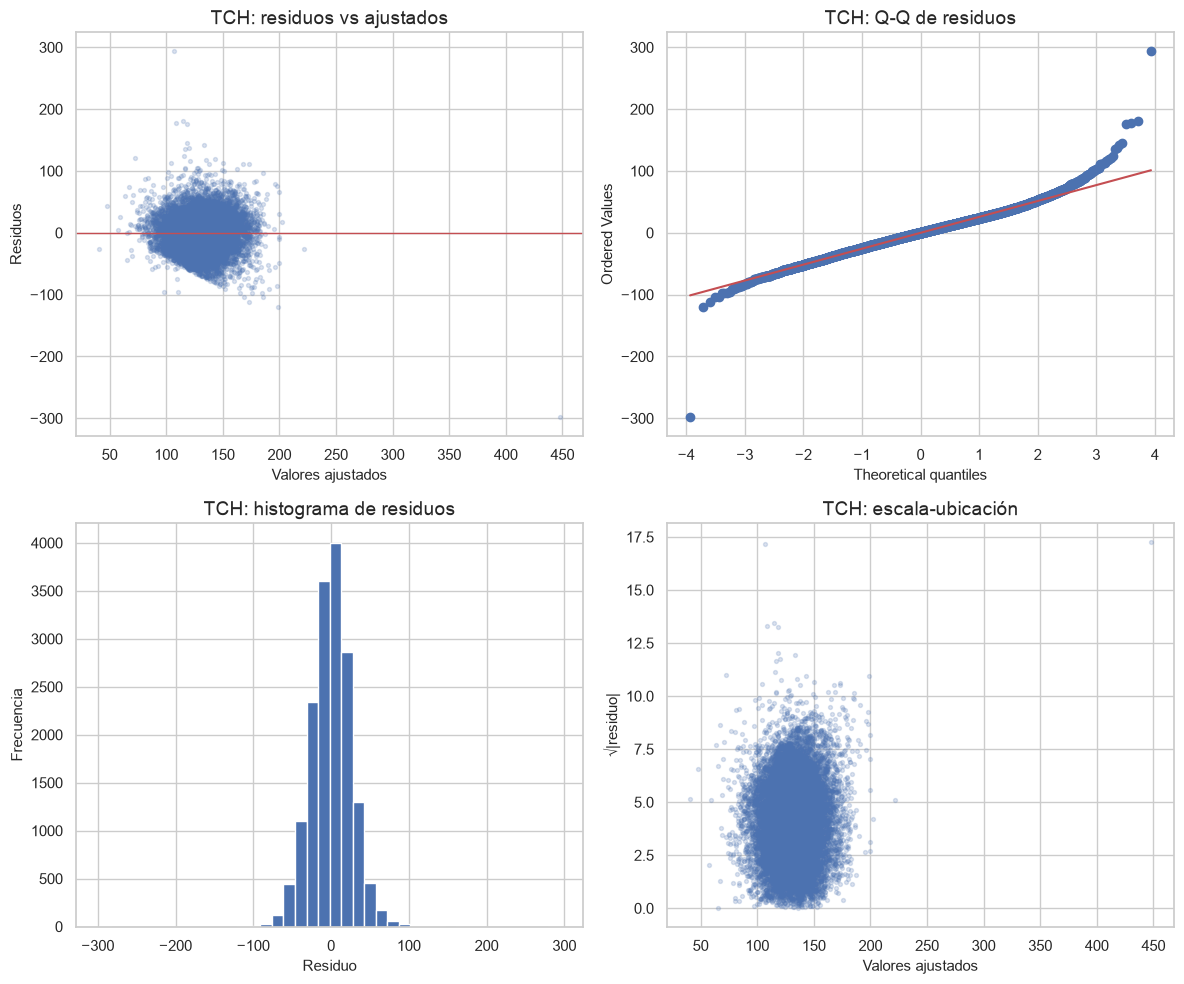

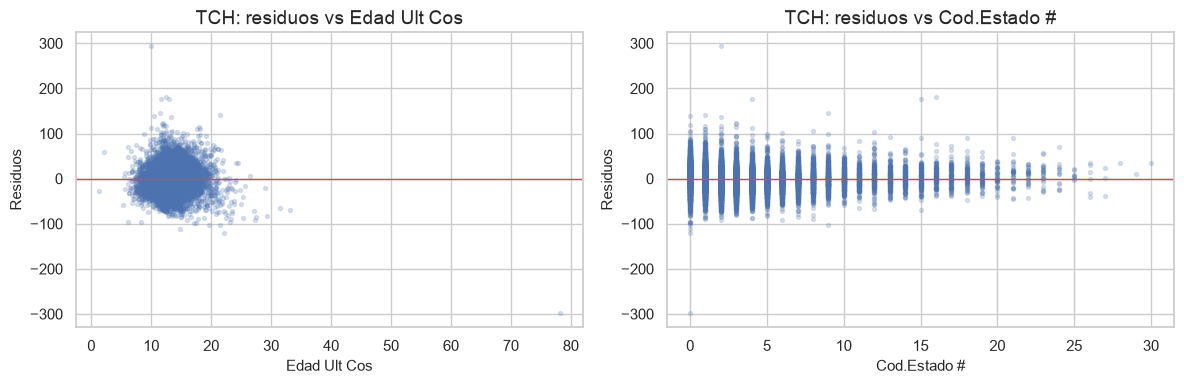

  Shapiro-Wilk (residuos, muestra n=5000): W = 0.9791  p = 1.72e-26
  Durbin-Watson (orden del train, post-shuffle): 1.996 (2 = sin autocorrelación; <2 = positiva; >2 = negativa)
TCH | n = 16,538  |  media residuo = -0.0000  |  asimetría = 0.161
  Breusch-Pagan (homocedasticidad): LM = 1298.9  p = 1.69e-233
  (p < 0.05 → se rechaza varianza constante; con este n el test es muy sensible)

--- %Sac.Caña ---


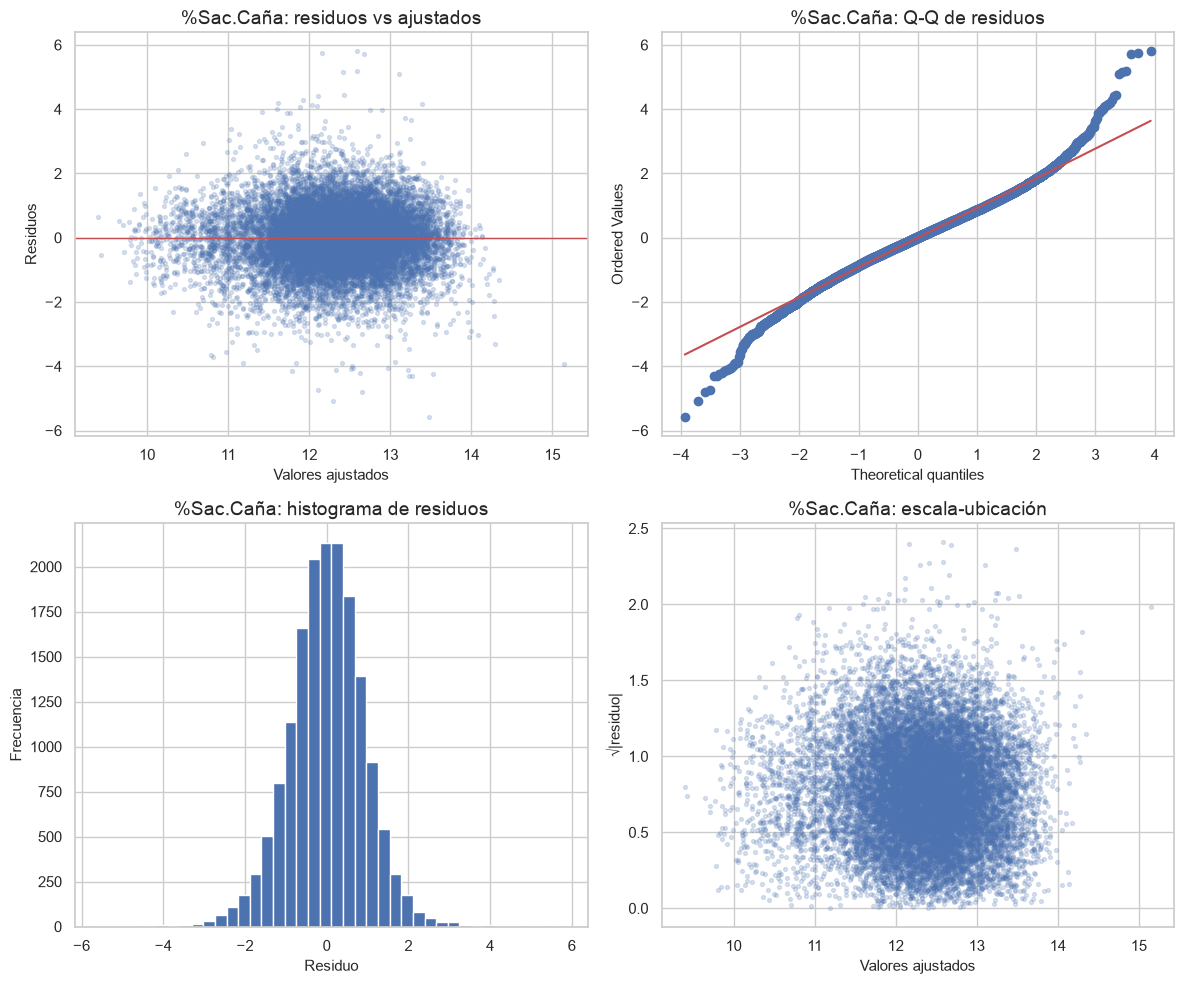

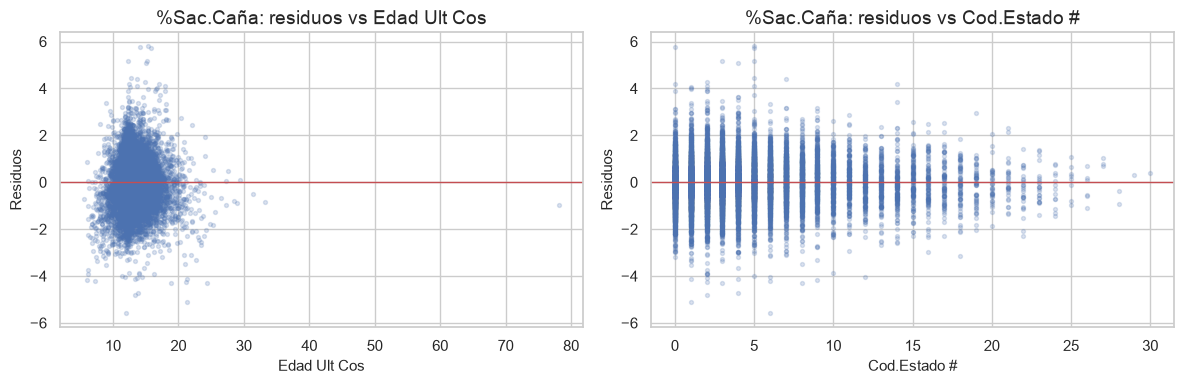

  Shapiro-Wilk (residuos, muestra n=5000): W = 0.9880  p = 3.58e-20
  Durbin-Watson (orden del train, post-shuffle): 1.996 (2 = sin autocorrelación; <2 = positiva; >2 = negativa)
%Sac.Caña | n = 16,479  |  media residuo = -0.0000  |  asimetría = -0.044
  Breusch-Pagan (homocedasticidad): LM = 670.9  p = 1.15e-105
  (p < 0.05 → se rechaza varianza constante; con este n el test es muy sensible)
log(TCH) — Breusch-Pagan: LM = 657.2  p = 2.08e-102  (comparar contra LM = 1298.9 de TCH sin transformar, línea de arriba)
TCH | Durbin-Watson ordenado por lote y período: 1.358 | lotes con más de un corte en train: 3,606
%Sac.Caña | Durbin-Watson ordenado por lote y período: 1.770 | lotes con más de un corte en train: 3,576

TCH | Cook máxima: 93.608535 | índice: 11531 | Edad Ult Cos = 8.25 | TCH = 65.04 | Destino 1=Semilla = 1
  ¿Es la fila de 78.19 meses del paso 9? False


In [7]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# het_breuschpagan: test de homocedasticidad (H0: Var(e) constante).
# Con n ≈ 16.800 el p-valor cae fácil; el gráfico residuos vs ŷ manda más que el p.

def diagnosticos_ols(modelo, X, nombre):
    """Supuestos del lineal: residuos vs ŷ, Q-Q, histograma, scale-location, residuos vs Edad/Cod.Estado, y Breusch-Pagan (H0: varianza constante)."""
    e = pd.Series(modelo.resid, index=getattr(modelo.resid, "index", None))
    yhat = pd.Series(modelo.fittedvalues, index=getattr(modelo.fittedvalues, "index", None))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].scatter(yhat, e, s=8, alpha=0.2, color="#4C72B0")
    axes[0, 0].axhline(0, color="#C44E52", lw=1)
    axes[0, 0].set_xlabel("Valores ajustados")
    axes[0, 0].set_ylabel("Residuos")
    axes[0, 0].set_title(f"{nombre}: residuos vs ajustados")

    stats.probplot(e, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title(f"{nombre}: Q-Q de residuos")

    axes[1, 0].hist(e, bins=40, color="#4C72B0", edgecolor="white")
    axes[1, 0].set_xlabel("Residuo")
    axes[1, 0].set_ylabel("Frecuencia")
    axes[1, 0].set_title(f"{nombre}: histograma de residuos")

    axes[1, 1].scatter(yhat, np.sqrt(np.abs(e)), s=8, alpha=0.2, color="#4C72B0")
    axes[1, 1].set_xlabel("Valores ajustados")
    axes[1, 1].set_ylabel("√|residuo|")
    axes[1, 1].set_title(f"{nombre}: escala-ubicación")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, col in zip(axes, ["Edad Ult Cos", "Cod.Estado #"]):
        ax.scatter(X[col], e, s=8, alpha=0.2, color="#4C72B0")
        ax.axhline(0, color="#C44E52", lw=1)
        ax.set_xlabel(col)
        ax.set_ylabel("Residuos")
        ax.set_title(f"{nombre}: residuos vs {col}")
    plt.tight_layout()
    plt.show()

    lm, lm_p, fstat, f_p = het_breuschpagan(e, modelo.model.exog)
    u_muestra = e.sample(min(5000, len(e)), random_state=0)  # mismo límite y semilla que el paso 7 de 01 (Shapiro no admite n grande)
    u_w, u_p_shapiro = stats.shapiro(u_muestra)
    print(f"  Shapiro-Wilk (residuos, muestra n={len(u_muestra)}): W = {u_w:.4f}  p = {u_p_shapiro:.2e}")
    from statsmodels.stats.stattools import durbin_watson

    dw_orden = durbin_watson(e.to_numpy())
    print(f"  Durbin-Watson (orden del train, post-shuffle): {dw_orden:.3f} (2 = sin autocorrelación; <2 = positiva; >2 = negativa)")
    print(
        f"{nombre} | n = {len(e):,}  |  "
        f"media residuo = {e.mean():.4f}  |  "
        f"asimetría = {e.skew():.3f}"
    )
    print(f"  Breusch-Pagan (homocedasticidad): LM = {lm:.1f}  p = {lm_p:.2e}")
    print("  (p < 0.05 → se rechaza varianza constante; con este n el test es muy sensible)")


print("--- TCH ---")
diagnosticos_ols(modelo_tch, X_train, "TCH")

print("\n--- %Sac.Caña ---")
diagnosticos_ols(modelo_sac, X_train_sac, "%Sac.Caña")

# Diagnóstico informativo: ¿log(TCH) mejora la homocedasticidad? No reemplaza al modelo del paso 18.
u_lm_tch, _, _, _ = het_breuschpagan(modelo_tch.resid, modelo_tch.model.exog)
u_log_tch = np.log(y_train_tch)
u_modelo_log = sm.OLS(u_log_tch, sm.add_constant(X_train, has_constant="add")).fit()
u_e_log = u_modelo_log.resid
u_lm_log, u_lmp_log, _, _ = het_breuschpagan(u_e_log, u_modelo_log.model.exog)
print(f"log(TCH) — Breusch-Pagan: LM = {u_lm_log:.1f}  p = {u_lmp_log:.2e}  "
      f"(comparar contra LM = {u_lm_tch:.1f} de TCH sin transformar, línea de arriba)")

def dw_por_lote(modelo, X, df_base, nombre):
    """Durbin-Watson sobre los residuos ordenados por (Hacienda, Suerte, Período): la prueba que corresponde a 'una suerte entra varias veces'."""
    e = pd.Series(modelo.resid, index=X.index)
    orden = df_base.loc[X.index, ["Hacienda", "Suerte", "Período"]].sort_values(["Hacienda", "Suerte", "Período"]).index
    dw = durbin_watson(e.loc[orden].to_numpy())
    n_lotes_rep = df_base.loc[X.index].groupby(["Hacienda", "Suerte"]).size().gt(1).sum()
    print(f"{nombre} | Durbin-Watson ordenado por lote y período: {dw:.3f} | lotes con más de un corte en train: {n_lotes_rep:,}")
    return dw

dw_tch = dw_por_lote(modelo_tch, X_train, df_tr, "TCH")
dw_sac = dw_por_lote(modelo_sac, X_train_sac, df_tr, "%Sac.Caña")

# Distancia de Cook en TCH: fila de mayor influencia (paso 9, Edad Ult Cos máx. 78.19).
cooks = pd.Series(modelo_tch.get_influence().cooks_distance[0], index=X_train.index, name="cooks_d")
idx_cook = cooks.idxmax()
fila_cook = df_tr.loc[idx_cook]
print(
    "\nTCH | Cook máxima:", round(float(cooks.loc[idx_cook]), 6),
    "| índice:", idx_cook,
    "| Edad Ult Cos =", round(float(fila_cook["Edad Ult Cos"]), 2),
    "| TCH =", round(float(fila_cook["TCH"]), 2),
    "| Destino 1=Semilla =", int(fila_cook["Destino 1=Semilla"]),
)
print("  ¿Es la fila de 78.19 meses del paso 9?", bool(np.isclose(float(fila_cook["Edad Ult Cos"]), 78.19, atol=0.005)))


In [8]:
# Por qué la distancia de Cook de la fila 11531 subió de 0.62 (con Tenencia cruda) a 93.61 (con Tenencia_agrup).
# Cook combina apalancamiento (leverage) y residuo: se separan para saber cuál disparó el salto.
u_infl = modelo_tch.get_influence()
u_hat = pd.Series(u_infl.hat_matrix_diag, index=X_train.index)
u_resid_std = pd.Series(u_infl.resid_studentized_internal, index=X_train.index)
print("Fila 11531 — leverage (hat):", round(float(u_hat.loc[idx_cook]), 6),
      "| percentil del leverage en train:", round(100 * (u_hat < u_hat.loc[idx_cook]).mean(), 2),
      "| residuo estudentizado:", round(float(u_resid_std.loc[idx_cook]), 3))
print("Leverage medio en train:", round(float(u_hat.mean()), 6), "| leverage máximo en train:", round(float(u_hat.max()), 6),
      "| ¿es esta fila el máximo?", bool(u_hat.idxmax() == idx_cook))

print("\nPerfil completo de la fila (todas las categóricas usadas en X):")
u_cols_cat_fila = ["Zona_agrup", "Variedad_agrup", "Suelo_agrup", "T.Corte_agrup", "Tipo Quema", "Cultivo", "Tenencia_agrup", "Mes"]
print(df_tr.loc[idx_cook, [c for c in u_cols_cat_fila if c in df_tr.columns]])

print("\n¿Cuántas filas de train comparten exactamente esta combinación de categóricas?")
u_mask_igual = pd.Series(True, index=df_tr.index)
for u_c in u_cols_cat_fila:
    if u_c in df_tr.columns:
        u_mask_igual &= (df_tr[u_c] == df_tr.loc[idx_cook, u_c])
print("Filas con la misma combinación exacta:", int(u_mask_igual.sum()))

print("\n¿La fila cae en Tenencia_agrup = OTRAS?", bool(df_tr.loc[idx_cook, "Tenencia_agrup"] == "OTRAS"))
if df_tr.loc[idx_cook, "Tenencia_agrup"] == "OTRAS":
    u_otras_idx = df_tr.loc[X_train.index].loc[df_tr.loc[X_train.index, "Tenencia_agrup"] == "OTRAS"].index
    print("Filas en train con Tenencia_agrup = OTRAS:", len(u_otras_idx))
    print("Leverage de esas filas — mediana:", round(float(u_hat.loc[u_otras_idx].median()), 6),
          "| máximo:", round(float(u_hat.loc[u_otras_idx].max()), 6))


Fila 11531 — leverage (hat): 1.0 | percentil del leverage en train: 99.99 | residuo estudentizado: -0.0
Leverage medio en train: 0.003568 | leverage máximo en train: 1.0 | ¿es esta fila el máximo? True

Perfil completo de la fila (todas las categóricas usadas en X):
Zona_agrup                  IP06
Variedad_agrup          CC05-430
Suelo_agrup       NUEVO PICHICHI
T.Corte_agrup              OTRAS
Tipo Quema                 VERDE
Cultivo                   Normal
Tenencia_agrup                11
Mes                           02
Name: 11531, dtype: str

¿Cuántas filas de train comparten exactamente esta combinación de categóricas?
Filas con la misma combinación exacta: 1

¿La fila cae en Tenencia_agrup = OTRAS? False


**Por qué subió la distancia de Cook**

La distancia de Cook de la fila 11531 es **93.61** porque su apalancamiento es el máximo posible, no porque el residuo sea grande. El leverage (hat) vale **1.0** (percentil **99.99** del train; media del train **0.003568**). Es la fila de mayor leverage. El residuo estudentizado es **−0.0**: con hat = 1 el lineal interpola ese punto y el residuo se va a cero; Cook explota por el término \(h/(1-h)^2\), que diverge cuando \(h \to 1\).

La combinación de categóricas de esta fila es única en train (**1** fila): `Zona_agrup` = IP06, `Variedad_agrup` = CC05-430, `Suelo_agrup` = NUEVO PICHICHI, `T.Corte_agrup` = **OTRAS**, `Tipo Quema` = VERDE, `Cultivo` = Normal, `Tenencia_agrup` = **11**, `Mes` = 02. **No** cae en `Tenencia_agrup` = OTRAS. El nivel raro es `T.Corte_agrup` = OTRAS (el `SEMILLA` recodificado del paso 16; una sola fila en train). Agrupar `Tenencia` no saca a esta fila de una dummy inestable de tenencia: cambia el diseño (sale una columna) y deja esta combinación ya única con hat = 1. El salto 0.62 → 93.61 es el mismo semillero, ahora con apalancamiento extremo, no un residuo nuevo.

**Decisión.** La fila sigue siendo un semillero de ciclo corto (TCH 65.04, `Edad Ult Cos` 8.25). Una distancia de Cook alta en una sola fila de 16.538 no invalida el modelo. El diagnóstico muestra que el apalancamiento viene de una combinación rara de categóricas (`T.Corte_agrup` = OTRAS, n = 1). Limitación adicional: el modelo tiene al menos una fila con apalancamiento alto por combinación rara de categóricas de baja frecuencia (`T.Corte_agrup` = OTRAS), un costo esperable de agrupar niveles pequeños en vez de eliminarlos: reduce la inestabilidad de las dummies pero puede concentrar apalancamiento en las pocas filas que quedan agrupadas.


**Qué muestra este paso**

Los gráficos son el criterio; el Breusch-Pagan solo cuantifica lo que ya se ve.

- **Linealidad.** Residuos vs ajustados no deben formar curva. Si vs `Cod.Estado #` queda un patrón (el TCH cae fuerte al inicio de la soca y luego se aplana), el lineal **promedia** esa no linealidad: el coef −0.6 t/ha por corte es una recta sobre un codo. `Edad Ult Cos` suele verse más plana (el efecto es más lineal).
- **Homocedasticidad.** Abanico en residuos vs ajustados y en escala-ubicación = varianza que crece con el TCH predicho (lotes chicos / extremos del paso 7). Breusch-Pagan casi seguro rechaza con n grande. Por eso se reportan **MAE y RMSE**: el RMSE castiga más esos puntos.
- **Normalidad.** El histograma de residuos es casi simétrico (como los targets). El Q-Q se sale en las colas. No impide interpretar signos; sí desaconseja intervalos que asuman gaussianidad estricta. Shapiro-Wilk (muestra de 5.000, misma razón que el paso 7 de 01): W = 0.9791, p = 1.72e-26 (TCH) y W = 0.9880, p = 3.58e-20 (sacarosa). Rechaza normalidad en los dos, coherente con lo que ya muestra el Q-Q; con este n cualquier desviación mínima alcanza para rechazar, así que el gráfico pesa más que el p-valor solo.
- **Independencia.** Una suerte entra varias veces (distintos `Período`). Los errores de un lote se parecen en el tiempo. Los p-valores del paso 18 están **optimistas**. Se anota; no se pone un modelo mixto aquí. Durbin-Watson en el orden del train (post-shuffle) es 1.996 (TCH) y 1.996 (sacarosa): cercano a 2, porque el shuffle del hold-out ya rompió el orden temporal y no es la prueba correcta. Ordenando por lote y periodo (3.606 lotes con más de un corte en train en TCH; 3.576 en sacarosa), Durbin-Watson da 1.358 y 1.770: ambos por debajo de 2 (más marcado en TCH) indican autocorrelación positiva entre cortes del mismo lote (el error de un corte se parece al del corte siguiente). Los errores estándar y los p-valores del paso 18 subestiman la incertidumbre real, así que la significancia de variables como `Edad Ult Cos` o `Cod.Estado #` debe leerse con cautela; los coeficientes (las magnitudes) siguen siendo válidos, no las pruebas de hipótesis.

**Influencia (Cook, TCH).** La distancia de Cook máxima es **93.61** (índice 11531): `Edad Ult Cos` = **8.25** meses, TCH = **65.04**, destino semilla. No corresponde a la fila de **78.19** meses del paso 9 (indeterminada). La observación que más tira del lineal es un semillero de ciclo corto, no el máximo de edad.

**Decisión.** El lineal cumple como **benchmark interpretable**, no como el proceso que generó el TCH. Limitaciones para el informe: soca no lineal, heterocedasticidad, lotes repetidos. La heterocedasticidad y la no linealidad del codo debilitan los intervalos de confianza y los p-valores del paso 18: los coeficientes (magnitudes y signos) siguen siendo la mejor lectura agronómica disponible, pero las pruebas de hipótesis exactas no. Log(TCH) da Breusch-Pagan LM = 657.2, frente a 1298.9 sin transformar: la transformación sí atenúa la heterocedasticidad, pero un coeficiente en escala logarítmica se lee como % de cambio, no como t/ha, y el Ingenio necesita t/ha para decidir. Por eso el paso 22 prueba Random Forest: no depende de linealidad ni de homocedasticidad, y sirve como comparación de desempeño frente a este mismo defecto del lineal. Siguiente: métricas en el **test** (R², RMSE, MAE), una sola vez.


## 20. Métricas en el test (hold-out)

Se reportan **R², RMSE y MAE** en el 20 % reservado. Ese bloque se toca **ahora**, una vez por modelo: no se vuelve a elegir variables ni a imputar. Train se muestra solo para ver sobreajuste.

Unidades: TCH en t/ha; `%Sac.Caña` en puntos porcentuales. No se comparan los dos R² entre sí como si fueran la misma escala. RMSE penaliza más los extremos (heterocedasticidad del paso 19); MAE es la lectura más estable.


Hold-out 80/20 — el test no se usó para ajustar


,modelo,conjunto,n,R²,RMSE,MAE
0,OLS TCH,train,16538,0.310,25.916,19.920
1,OLS TCH,test,4134,0.324,26.259,20.317
2,OLS %Sac.Caña,train,16479,0.348,0.930,0.714
3,OLS %Sac.Caña,test,4099,0.350,0.907,0.706


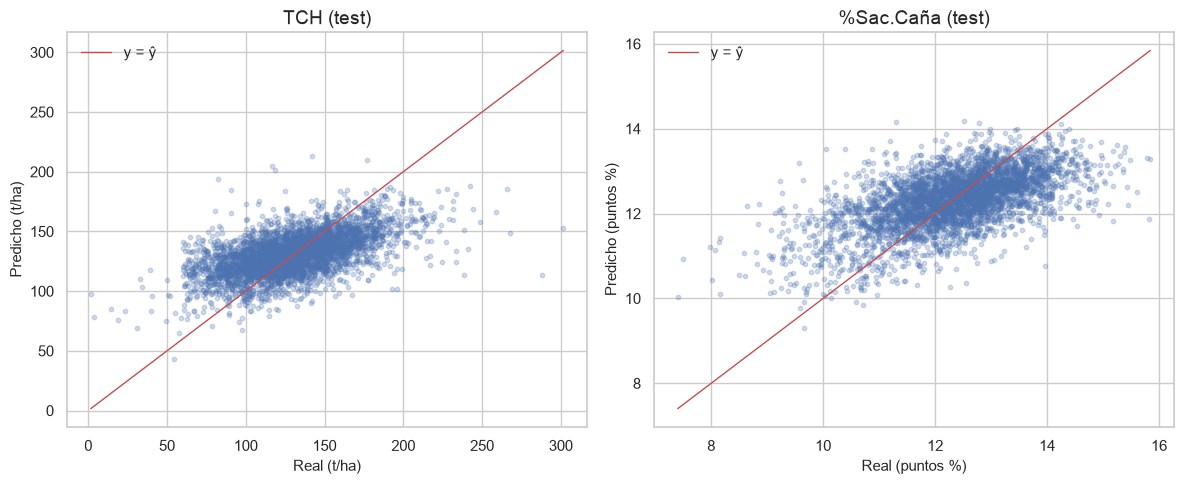

Sesgo medio en test (real − predicho): TCH -1.40 t/ha  |  %Sac -0.008 puntos
Error por decil de %Sac.Caña real (test):


,n,MAE,real_medio,pred_medio
real,,,,
"(7.401, 10.875]",410,1.339,10.173,11.477
"(10.875, 11.45]",410,0.843,11.184,11.947
"(11.45, 11.787]",410,0.608,11.632,12.130
"(11.787, 12.108]",410,0.473,11.957,12.205
"(12.108, 12.369]",410,0.402,12.238,12.297
"(12.369, 12.64]",410,0.401,12.506,12.388
"(12.64, 12.906]",409,0.437,12.774,12.536
"(12.906, 13.241]",410,0.551,13.065,12.609
"(13.241, 13.691]",410,0.709,13.453,12.768


MAE decil más bajo: 1.339 | MAE decil más alto: 1.302 | MAE global: 0.706


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# R², RMSE y MAE en train (ajuste) y test (generalización).
# El test no se usó para elegir predictores ni para imputar.

def metricas(y_true, y_pred):
    """R², RMSE y MAE. RMSE penaliza más los errores grandes (heterocedasticidad); MAE es t/ha o puntos de sacarosa en promedio."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "n": int(len(y_true)),
        "R²": r2_score(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
    }


def predecir_ols(modelo, X):
    """Predicción del OLS alineando columnas con las del ajuste (añade constante y reindexa). Sirve para train y test."""
    Xc = sm.add_constant(X, has_constant="add")
    Xc = Xc.reindex(columns=modelo.model.exog_names, fill_value=0.0)
    return modelo.predict(Xc)


pred_tr_tch = predecir_ols(modelo_tch, X_train)
pred_te_tch = predecir_ols(modelo_tch, X_test)
pred_tr_sac = predecir_ols(modelo_sac, X_train_sac)
pred_te_sac = predecir_ols(modelo_sac, X_test_sac)

tabla_metricas = pd.DataFrame([
    {"modelo": "OLS TCH", "conjunto": "train", **metricas(y_train_tch, pred_tr_tch)},
    {"modelo": "OLS TCH", "conjunto": "test", **metricas(y_test_tch, pred_te_tch)},
    {"modelo": "OLS %Sac.Caña", "conjunto": "train", **metricas(y_train_sac, pred_tr_sac)},
    {"modelo": "OLS %Sac.Caña", "conjunto": "test", **metricas(y_test_sac, pred_te_sac)},
])
print("Hold-out 80/20 — el test no se usó para ajustar")
display(tabla_metricas.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y, yhat, titulo, unidad in [
    (axes[0], y_test_tch, pred_te_tch, "TCH (test)", "t/ha"),
    (axes[1], y_test_sac, pred_te_sac, "%Sac.Caña (test)", "puntos %"),
]:
    ax.scatter(y, yhat, s=10, alpha=0.25, color="#4C72B0")
    lo = min(np.min(y), np.min(yhat))
    hi = max(np.max(y), np.max(yhat))
    ax.plot([lo, hi], [lo, hi], color="#C44E52", lw=1, label="y = ŷ")
    ax.set_xlabel(f"Real ({unidad})")
    ax.set_ylabel(f"Predicho ({unidad})")
    ax.set_title(titulo)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(
    "Sesgo medio en test (real − predicho): "
    f"TCH {np.mean(np.asarray(y_test_tch) - pred_te_tch):.2f} t/ha  |  "
    f"%Sac {np.mean(np.asarray(y_test_sac) - pred_te_sac):.3f} puntos"
)
# Error del modelo en los extremos de %Sac.Caña: ¿el lineal sigue alertando en los lotes críticos?
u_pred_sac = pred_te_sac
u_res = pd.DataFrame({"real": y_test_sac.to_numpy(), "pred": np.asarray(u_pred_sac)})
u_res["error_abs"] = (u_res["real"] - u_res["pred"]).abs()
u_dec = pd.qcut(u_res["real"], 10, duplicates="drop")
u_tab = u_res.groupby(u_dec, observed=True).agg(n=("real", "size"), MAE=("error_abs", "mean"),
                                                 real_medio=("real", "mean"), pred_medio=("pred", "mean"))
print("Error por decil de %Sac.Caña real (test):")
display(u_tab.round(3))
print("MAE decil más bajo:", round(u_tab['MAE'].iloc[0], 3), "| MAE decil más alto:", round(u_tab['MAE'].iloc[-1], 3),
      "| MAE global:", round(u_res['error_abs'].mean(), 3))


**Qué muestra este paso**

- **Test vs train.** TCH: R² train **0.310** / test **0.324**; RMSE 25.916 / 26.259; MAE 19.920 / 20.317 (n test = 4.134). Sacarosa: R² **0.348** / **0.350**; RMSE 0.930 / 0.907; MAE 0.714 / 0.706 (n test = 4.099). El lineal no se memorizó el 80%.
- **TCH.** MAE **20.4 t/ha** es lo que un ingenio entiende. RMSE > MAE confirma colas (lotes chicos / semilla del paso 7). Sesgo de test: **−1.40 t/ha**.
- **`%Sac.Caña`.** La dosis y las lluvias de maduración mueven la calidad; el error se lee en puntos de sacarosa. Sesgo de test: **−0.008** puntos.

**¿Es sacarosa 'fácil' por estar concentrada?** El coeficiente de variación de `%Sac.Caña` es **9.3 %** (desviación 1.15 sobre media 12.32), menos de la mitad que el de TCH (**25.3 %**, desviación 32.85 sobre media 129.61, paso 7 de 01): el target sí está objetivamente más concentrado. Pero eso no hace el error del modelo chico en términos de negocio. El MAE de test (**0.706** puntos) es **1.36 veces** el efecto de `Dosis Madurante` (**+0.52** puntos por unidad, paso 18), la palanca de manejo más clara que el modelo identifica para subir la calidad: en promedio, el error típico del modelo es **mayor** que el cambio que produce aplicar o no madurante. Una diferencia de 0.5 puntos, que parece chica frente al rango 7–18 % del target, es del mismo orden que la decisión operativa completa de madurar o no un lote.
- **Extremos de sacarosa (test).** MAE del decil más bajo **1.339** y del más alto **1.302**, frente a un MAE global de **0.706**. El modelo pierde precisión justo donde el Ingenio más necesita alertar: mayor error en los lotes de desempeño más bajo y más alto. En el decil bajo predice 11.48 frente a 10.17 real; en el alto, 12.87 frente a 14.17.
- **Nube real vs predicho.** Debe seguir la diagonal. Abanico al subir el TCH = la heterocedasticidad del paso 19, no un bug del split.
- El test **no se reutiliza** para tirar variables ni para elegir Ridge. Eso es el paso 21 (k-fold en train).

**Decisión.** Quedan las métricas de hold-out del benchmark. Siguiente: **k-fold (k = 5) sobre el train** para un RMSE/R² más estable; Ridge/Lasso como comparación de regularización.


In [10]:
# ¿El mismo lote (Hacienda+Suerte) aparece en train y en test? Si sí, el R² de test
# puede estar inflado por lotes que el modelo ya "conoce" a través de Zona/Suelo/Variedad/Dist Km.
u_lote_tr = set(df_train[["Hacienda", "Suerte"]].apply(tuple, axis=1))
u_lote_te_tch = df_te.loc[df_te["excluir_tch"] == False, ["Hacienda", "Suerte"]].apply(tuple, axis=1)
u_visto_tch = u_lote_te_tch.isin(u_lote_tr)
print("--- TCH ---")
print(f"Lotes distintos en train: {len(u_lote_tr):,} | filas de test: {len(u_lote_te_tch):,}")
print(f"Filas de test cuyo lote también está en train: {int(u_visto_tch.sum()):,} "
      f"({100 * u_visto_tch.mean():.1f} %) | lote genuinamente nuevo: {int((~u_visto_tch).sum()):,} "
      f"({100 * (~u_visto_tch).mean():.1f} %)")

u_err_tch = pd.DataFrame({"real": y_test_tch.to_numpy(), "pred": np.asarray(pred_te_tch),
                          "lote_visto": u_visto_tch.to_numpy()})
u_err_tch["error_abs"] = (u_err_tch["real"] - u_err_tch["pred"]).abs()
display(u_err_tch.groupby("lote_visto").agg(n=("error_abs", "size"), MAE=("error_abs", "mean"),
                                            RMSE=("error_abs", lambda e: np.sqrt((e**2).mean()))).round(3))

print("\n--- %Sac.Caña ---")
u_lote_te_sac = df_te.loc[df_te["%Sac.Caña"].notna(), ["Hacienda", "Suerte"]].apply(tuple, axis=1)
u_visto_sac = u_lote_te_sac.isin(u_lote_tr)
print(f"Filas de test cuyo lote también está en train: {int(u_visto_sac.sum()):,} "
      f"({100 * u_visto_sac.mean():.1f} %) | lote genuinamente nuevo: {int((~u_visto_sac).sum()):,} "
      f"({100 * (~u_visto_sac).mean():.1f} %)")

u_err_sac = pd.DataFrame({"real": y_test_sac.to_numpy(), "pred": np.asarray(pred_te_sac),
                          "lote_visto": u_visto_sac.to_numpy()})
u_err_sac["error_abs"] = (u_err_sac["real"] - u_err_sac["pred"]).abs()
display(u_err_sac.groupby("lote_visto").agg(n=("error_abs", "size"), MAE=("error_abs", "mean"),
                                            RMSE=("error_abs", lambda e: np.sqrt((e**2).mean()))).round(3))


--- TCH ---
Lotes distintos en train: 5,409 | filas de test: 4,134
Filas de test cuyo lote también está en train: 3,708 (89.7 %) | lote genuinamente nuevo: 426 (10.3 %)


,n,MAE,RMSE
lote_visto,,,
False,426,22.722,29.416
True,3708,20.041,25.872



--- %Sac.Caña ---


Filas de test cuyo lote también está en train: 3,678 (89.7 %) | lote genuinamente nuevo: 421 (10.3 %)


,n,MAE,RMSE
lote_visto,,,
False,421,0.825,1.084
True,3678,0.693,0.885


**¿El modelo generaliza a un lote nuevo?**

El 80/20 del paso 15 parte por fila, no por `Hacienda`+`Suerte`. En TCH, **89.7 %** de las filas de test (3.708 de 4.134) pertenecen a un lote que también está en train; solo **10.3 %** (426) es un lote genuinamente nuevo. En `%Sac.Caña` el solape es el mismo: **89.7 %** (3.678) vs **10.3 %** (421). Train tiene 5.409 lotes distintos.

El error es menor cuando el lote ya apareció en train. TCH: MAE **20.041** / RMSE **25.872** (lote visto) frente a MAE **22.722** / RMSE **29.416** (lote nuevo). Sacarosa: MAE **0.693** / RMSE **0.885** frente a MAE **0.825** / RMSE **1.084**. El modelo generaliza peor a un lote genuinamente nuevo: MAE 22.722 vs 20.041 (TCH) y 0.825 vs 0.693 (sacarosa).

Eso y el Durbin-Watson del paso 19 (1.358 en TCH y 1.770 en sacarosa, residuos ordenados por lote y periodo) salen de la misma causa: un lote entra varias veces. Contestan preguntas distintas. Durbin-Watson dice que los p-valores del OLS del paso 18 son optimistas (autocorrelación positiva entre cortes). El solape dice que el R²/MAE de test del paso 20 estima de más el desempeño en un lote que el lineal no ha visto.

Ningún identificador de lote (`Nombre`, `Hacienda`, `Suerte`) entra a X (paso 4). `Variedad_agrup` y `Suelo_agrup` van agrupadas por frecuencia, no son el código crudo del lote. El riesgo no es una variable identificadora: es que el split no separa por lote.

**Decisión.** Es una limitación real del hold-out actual. La alternativa correcta es dividir por lote (`GroupShuffleSplit` de sklearn, agrupando por `Hacienda`+`Suerte`) para que ningún lote aparezca en ambos lados. No se reajusta el split aquí; queda como limitación para el informe.

**¿Cambia esto las secciones 18–19 y 21–22?** No: los modelos y sus métricas no se reajustan aquí. Esto documenta qué tan confiable es el número de test como estimador de generalización a un lote nuevo.


## 21. Validación cruzada en el train (k = 5)

K-fold **sobre el entrenamiento** (k = 5) para estimar el desempeño y, si hay hiperparámetros, elegirlos. El OLS no tiene hiperparámetro: el CV da un RMSE/R² más estable que un solo train. **Ridge** (y Lasso) sí eligen `alpha` por CV en train; el test se evalúa **después**, una vez.

La imputación y las dummies ya se fijaron con todo el train (paso 16): el k-fold de este paso estima el error del lineal sobre esa matriz, no reimputa en cada fold (anidarlo sería el siguiente nivel de rigor). Ridge/Lasso van con `StandardScaler` en un pipeline: la penalización depende de la escala.


In [11]:
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Modelos sklearn de esta celda (el OLS interpretable sigue siendo statsmodels, paso 18):
# - LinearRegression: MCO sin penalizar. Sirve para k-fold comparable a Ridge/Lasso.
# - Ridge: penaliza Σ β² (encoge, no apaga). Pipeline StandardScaler → Ridge(max_iter=10_000).
# - Lasso: penaliza Σ |β| (puede dejar β=0). Mismo scaler; max_iter=20_000 (converge más lento).
# Hiperparámetro alpha: grilla logspace(-2, 4, 20) → 0.01 … 10.000. Se elige el de menor RMSE de CV.
# Validación: KFold(k=5, shuffle=True, random_state=42) SOLO en train. GridSearchCV scoring =
# neg_root_mean_squared_error; n_jobs=1; refit=True (reajusta con alpha* en todo el train).

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
}


def resumen_cv(est, X, y, nombre):
    """K-fold sobre un estimador sklearn: media y desvío de R², RMSE y MAE. sklearn reporta RMSE/MAE en negativo; aquí se vuelven a positivo."""
    cvres = cross_validate(est, X, y, cv=cv, scoring=scoring)
    fila = {
        "modelo": nombre,
        "R²_CV": cvres["test_R2"].mean(),
        "R²_CV_sd": cvres["test_R2"].std(),
        "RMSE_CV": -cvres["test_RMSE"].mean(),
        "RMSE_CV_sd": cvres["test_RMSE"].std(),
        "MAE_CV": -cvres["test_MAE"].mean(),
        "MAE_CV_sd": cvres["test_MAE"].std(),
    }
    print(
        f"{nombre}: R² {fila['R²_CV']:.3f} ± {fila['R²_CV_sd']:.3f}  |  "
        f"RMSE {fila['RMSE_CV']:.3f} ± {fila['RMSE_CV_sd']:.3f}  |  "
        f"MAE {fila['MAE_CV']:.3f} ± {fila['MAE_CV_sd']:.3f}"
    )
    return fila


def ajustar_penalizado(estimador, grilla, X_tr, y_tr, X_te, y_te, nombre):
    """Pipeline StandardScaler → Ridge o Lasso. GridSearchCV elige alpha minimizando RMSE de CV (refit=True). El test se evalúa una sola vez, con alpha ya fijado."""
    pipe = Pipeline([
        ("escala", StandardScaler()),
        ("modelo", estimador),
    ])
    gs = GridSearchCV(
        pipe,
        param_grid=grilla,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
        refit=True,
    )
    gs.fit(X_tr, y_tr)
    alpha = gs.best_params_["modelo__alpha"]
    pred_te = gs.predict(X_te)
    rmse_cv_sd = float(gs.cv_results_["std_test_score"][gs.best_index_])
    met_te = metricas(y_te, pred_te)
    print(
        f"{nombre}: alpha* = {alpha:.4g}  |  "
        f"RMSE CV = {-gs.best_score_:.3f}  |  "
        f"test R² = {met_te['R²']:.3f}  RMSE = {met_te['RMSE']:.3f}  MAE = {met_te['MAE']:.3f}"
    )
    return gs, {
        "modelo": nombre,
        "alpha": alpha,
        "RMSE_CV": -gs.best_score_,
        "RMSE_CV_sd": rmse_cv_sd,
        **{f"{k}_test": v for k, v in met_te.items() if k != "n"},
    }


print("OLS — k-fold k=5 en train (sin tocar el test)")
filas_cv = [
    resumen_cv(LinearRegression(), X_train, y_train_tch, "OLS TCH"),
    resumen_cv(LinearRegression(), X_train_sac, y_train_sac, "OLS %Sac.Caña"),
]
display(pd.DataFrame(filas_cv).round(3))

alphas = np.logspace(-2, 4, 20)
print("\nRidge / Lasso — alpha por CV en train; métricas de test al final")
gs_ridge_tch, r1 = ajustar_penalizado(
    Ridge(max_iter=10000), {"modelo__alpha": alphas},
    X_train, y_train_tch, X_test, y_test_tch, "Ridge TCH",
)
gs_ridge_sac, r2 = ajustar_penalizado(
    Ridge(max_iter=10000), {"modelo__alpha": alphas},
    X_train_sac, y_train_sac, X_test_sac, y_test_sac, "Ridge %Sac.Caña",
)
gs_lasso_tch, r3 = ajustar_penalizado(
    Lasso(max_iter=20000), {"modelo__alpha": alphas},
    X_train, y_train_tch, X_test, y_test_tch, "Lasso TCH",
)
gs_lasso_sac, r4 = ajustar_penalizado(
    Lasso(max_iter=20000), {"modelo__alpha": alphas},
    X_train_sac, y_train_sac, X_test_sac, y_test_sac, "Lasso %Sac.Caña",
)

ols_test = tabla_metricas.loc[tabla_metricas["conjunto"] == "test"].copy()
comparacion = pd.DataFrame([
    {"modelo": "OLS TCH", "RMSE_CV": filas_cv[0]["RMSE_CV"], "RMSE_CV_sd": filas_cv[0]["RMSE_CV_sd"], "R²_test": ols_test.loc[ols_test["modelo"]=="OLS TCH", "R²"].iloc[0], "RMSE_test": ols_test.loc[ols_test["modelo"]=="OLS TCH", "RMSE"].iloc[0], "MAE_test": ols_test.loc[ols_test["modelo"]=="OLS TCH", "MAE"].iloc[0]},
    {"modelo": "Ridge TCH", **{k: r1[k] for k in ["RMSE_CV", "RMSE_CV_sd"]}, "R²_test": r1["R²_test"], "RMSE_test": r1["RMSE_test"], "MAE_test": r1["MAE_test"]},
    {"modelo": "Lasso TCH", "RMSE_CV": r3["RMSE_CV"], "RMSE_CV_sd": r3["RMSE_CV_sd"], "R²_test": r3["R²_test"], "RMSE_test": r3["RMSE_test"], "MAE_test": r3["MAE_test"]},
    {"modelo": "OLS %Sac.Caña", "RMSE_CV": filas_cv[1]["RMSE_CV"], "RMSE_CV_sd": filas_cv[1]["RMSE_CV_sd"], "R²_test": ols_test.loc[ols_test["modelo"]=="OLS %Sac.Caña", "R²"].iloc[0], "RMSE_test": ols_test.loc[ols_test["modelo"]=="OLS %Sac.Caña", "RMSE"].iloc[0], "MAE_test": ols_test.loc[ols_test["modelo"]=="OLS %Sac.Caña", "MAE"].iloc[0]},
    {"modelo": "Ridge %Sac.Caña", "RMSE_CV": r2["RMSE_CV"], "RMSE_CV_sd": r2["RMSE_CV_sd"], "R²_test": r2["R²_test"], "RMSE_test": r2["RMSE_test"], "MAE_test": r2["MAE_test"]},
    {"modelo": "Lasso %Sac.Caña", "RMSE_CV": r4["RMSE_CV"], "RMSE_CV_sd": r4["RMSE_CV_sd"], "R²_test": r4["R²_test"], "RMSE_test": r4["RMSE_test"], "MAE_test": r4["MAE_test"]},
])
print("\nComparación (CV en train; test una sola vez)")
display(comparacion.round(3))

# Lasso: cuántas variables quedan (selección por penalización L1)
def n_coef_lasso(gs):
    """Cuántos coeficientes Lasso dejó distintos de cero (|β|>1e-8). Resumen de la selección por penalización L1."""
    coef = gs.best_estimator_.named_steps["modelo"].coef_
    return int(np.sum(np.abs(coef) > 1e-8)), int(len(coef))

n1, p1 = n_coef_lasso(gs_lasso_tch)
n2, p2 = n_coef_lasso(gs_lasso_sac)
print(f"Lasso TCH: {n1} / {p1} coeficientes ≠ 0")
print(f"Lasso %Sac.Caña: {n2} / {p2} coeficientes ≠ 0")

# Qué variables quedan en cero (selección de Lasso, no solo el conteo).
def coef_lasso_cero(gs, cols):
    coef = gs.best_estimator_.named_steps["modelo"].coef_
    return sorted([c for c, b in zip(cols, np.abs(coef) <= 1e-8) if b])

cero_tch = coef_lasso_cero(gs_lasso_tch, X_train.columns)
cero_sac = coef_lasso_cero(gs_lasso_sac, X_train_sac.columns)
print("Lasso TCH — variables en 0:", cero_tch)
print("Lasso %Sac.Caña — variables en 0:", cero_sac)


OLS — k-fold k=5 en train (sin tocar el test)


OLS TCH: R² 0.301 ± 0.012  |  RMSE 26.074 ± 0.338  |  MAE 20.027 ± 0.037
OLS %Sac.Caña: R² 0.342 ± 0.010  |  RMSE 0.933 ± 0.009  |  MAE 0.717 ± 0.006


,modelo,R²_CV,R²_CV_sd,RMSE_CV,RMSE_CV_sd,MAE_CV,MAE_CV_sd
0,OLS TCH,0.301,0.012,26.074,0.338,20.027,0.037
1,OLS %Sac.Caña,0.342,0.010,0.933,0.009,0.717,0.006



Ridge / Lasso — alpha por CV en train; métricas de test al final


Ridge TCH: alpha* = 127.4  |  RMSE CV = 26.074  |  test R² = 0.323  RMSE = 26.267  MAE = 20.322


Ridge %Sac.Caña: alpha* = 127.4  |  RMSE CV = 0.933  |  test R² = 0.350  RMSE = 0.907  MAE = 0.706


Lasso TCH: alpha* = 0.02069  |  RMSE CV = 26.075  |  test R² = 0.324  RMSE = 26.259  MAE = 20.318


Lasso %Sac.Caña: alpha* = 0.01  |  RMSE CV = 0.936  |  test R² = 0.344  RMSE = 0.912  MAE = 0.709

Comparación (CV en train; test una sola vez)


,modelo,RMSE_CV,RMSE_CV_sd,R²_test,RMSE_test,MAE_test
0,OLS TCH,26.074,0.338,0.324,26.259,20.317
1,Ridge TCH,26.074,0.341,0.323,26.267,20.322
2,Lasso TCH,26.075,0.347,0.324,26.259,20.318
3,OLS %Sac.Caña,0.933,0.009,0.350,0.907,0.706
4,Ridge %Sac.Caña,0.933,0.009,0.350,0.907,0.706
5,Lasso %Sac.Caña,0.936,0.009,0.344,0.912,0.709


Lasso TCH: 57 / 58 coeficientes ≠ 0
Lasso %Sac.Caña: 47 / 57 coeficientes ≠ 0
Lasso TCH — variables en 0: ['Mes_06']
Lasso %Sac.Caña — variables en 0: ['Destino 1=Semilla', 'Lluvias seis a nueve', 'Lluvias tres a seis', 'Num.Riegos', 'Suelo_agrup_CORINTIAS', 'Suelo_agrup_PALMERAS', 'Suelo_agrup_PALMIRA', 'Tenencia_agrup_OTRAS', 'Zona_agrup_IP02', 'Zona_agrup_IP06']


In [12]:
# Ingeniería de características: ¿lluvia_sin_dato, Año y Mes agregan valor real vía CV, o son complejidad de más?
u_mes_cols = [c for c in X_train.columns if c.startswith("Mes_")]
u_features_nuevas = {"lluvia_sin_dato": ["lluvia_sin_dato"], "Año": ["Año"], "Mes": u_mes_cols}

print("--- Con vs sin cada característica derivada (mismo cv de 5 folds; LinearRegression) ---")
u_filas_ablacion = []
for u_nombre_feat, u_cols_feat in u_features_nuevas.items():
    for u_target, u_X, u_y in (("TCH", X_train, y_train_tch), ("%Sac.Caña", X_train_sac, y_train_sac)):
        u_cols_feat_presentes = [c for c in u_cols_feat if c in u_X.columns]
        if not u_cols_feat_presentes:
            continue
        u_con = resumen_cv(LinearRegression(), u_X, u_y, f"con {u_nombre_feat} ({u_target})")
        u_sin = resumen_cv(LinearRegression(), u_X.drop(columns=u_cols_feat_presentes), u_y, f"sin {u_nombre_feat} ({u_target})")
        u_filas_ablacion.append({
            "característica": u_nombre_feat, "target": u_target,
            "R²_CV con": u_con["R²_CV"], "R²_CV sin": u_sin["R²_CV"],
            "ΔR²_CV": u_con["R²_CV"] - u_sin["R²_CV"],
            "RMSE_CV con": u_con["RMSE_CV"], "RMSE_CV sin": u_sin["RMSE_CV"],
            "ΔRMSE_CV": u_sin["RMSE_CV"] - u_con["RMSE_CV"],
        })
display(pd.DataFrame(u_filas_ablacion).round(4))


--- Con vs sin cada característica derivada (mismo cv de 5 folds; LinearRegression) ---
con lluvia_sin_dato (TCH): R² 0.301 ± 0.012  |  RMSE 26.074 ± 0.338  |  MAE 20.027 ± 0.037
sin lluvia_sin_dato (TCH): R² 0.297 ± 0.013  |  RMSE 26.153 ± 0.362  |  MAE 20.108 ± 0.048
con lluvia_sin_dato (%Sac.Caña): R² 0.342 ± 0.010  |  RMSE 0.933 ± 0.009  |  MAE 0.717 ± 0.006


sin lluvia_sin_dato (%Sac.Caña): R² 0.341 ± 0.010  |  RMSE 0.934 ± 0.009  |  MAE 0.717 ± 0.005
con Año (TCH): R² 0.301 ± 0.012  |  RMSE 26.074 ± 0.338  |  MAE 20.027 ± 0.037
sin Año (TCH): R² 0.270 ± 0.014  |  RMSE 26.649 ± 0.378  |  MAE 20.430 ± 0.074
con Año (%Sac.Caña): R² 0.342 ± 0.010  |  RMSE 0.933 ± 0.009  |  MAE 0.717 ± 0.006


sin Año (%Sac.Caña): R² 0.342 ± 0.010  |  RMSE 0.933 ± 0.009  |  MAE 0.717 ± 0.006
con Mes (TCH): R² 0.301 ± 0.012  |  RMSE 26.074 ± 0.338  |  MAE 20.027 ± 0.037
sin Mes (TCH): R² 0.299 ± 0.012  |  RMSE 26.118 ± 0.336  |  MAE 20.067 ± 0.047
con Mes (%Sac.Caña): R² 0.342 ± 0.010  |  RMSE 0.933 ± 0.009  |  MAE 0.717 ± 0.006
sin Mes (%Sac.Caña): R² 0.264 ± 0.010  |  RMSE 0.987 ± 0.008  |  MAE 0.764 ± 0.005


,característica,target,R²_CV con,R²_CV sin,ΔR²_CV,RMSE_CV con,RMSE_CV sin,ΔRMSE_CV
0,lluvia_sin_dato,TCH,0.3012,0.2970,0.0043,26.0742,26.1534,0.0792
1,lluvia_sin_dato,%Sac.Caña,0.3420,0.3411,0.0008,0.9333,0.9339,0.0006
2,Año,TCH,0.3012,0.2701,0.0312,26.0742,26.6489,0.5747
3,Año,%Sac.Caña,0.3420,0.3420,-0.0001,0.9333,0.9333,-0.0000
4,Mes,TCH,0.3012,0.2988,0.0024,26.0742,26.1183,0.0441
5,Mes,%Sac.Caña,0.3420,0.2643,0.0777,0.9333,0.9869,0.0535


**Ingeniería de características: ¿valor real o complejidad?**

Misma `LinearRegression` y el mismo `cv` de 5 folds del paso 21; se quita una característica a la vez. ΔR²_CV > 0 y ΔRMSE_CV > 0 significan que incluirla mejora el CV.

- **`lluvia_sin_dato`.** En TCH el CV baja poco al quitarla (R² 0.3012 → 0.2970, ΔR² = 0.0043; RMSE 26.074 → 26.153, ΔRMSE = 0.079). En sacarosa el cambio es mínimo (ΔR² = 0.0008; ΔRMSE = 0.0006). No es complejidad vacía en TCH, pero el aporte es chico frente al de `Año` o `Mes`. Tiene sentido agronómico propio: marca un vacío de captura, no una recombinación algebraica de otra X ya en el modelo.
- **`Año`.** En TCH agrega valor real: sin él el R²_CV cae **0.0312** (0.3012 → 0.2701) y el RMSE sube **0.575** t/ha. En sacarosa no aporta (ΔR² = −0.0001; ΔRMSE ≈ 0), coherente con el OLS del paso 18 (p = 0.55). Es tendencia interanual, no estacionalidad.
- **`Mes`.** En TCH el cambio es mínimo (ΔR² = 0.0024; ΔRMSE = 0.044). En sacarosa agrega valor real: sin las dummies de mes el R²_CV cae **0.0777** (0.3420 → 0.2643) y el RMSE sube **0.054** puntos. Es estacionalidad dentro del año, no la tendencia de `Año`.

`Año` y `Mes` salen de la misma columna (`Período`) y no se vuelven redundantes: `Año` mueve TCH y casi no toca sacarosa; `Mes` mueve sacarosa y casi no toca TCH. `lluvia_sin_dato` es independiente de ese par.

`madurada` y `edad_desde_siembra` pasaron por la misma pregunta antes, por VIF en vez de por CV (pasos 12 y 17 de 01/02), y ambas se descartaron por ser recombinaciones colineales de variables ya en el modelo, no por agregar poco en CV.

**¿Cambia esto las secciones 18–23?** No: es una verificación aparte del modelo principal, que ya incluye estas tres características. **No se reescribe el resto del notebook.**


In [13]:
# Verificación completa (no solo el top 12 impreso) de si las variables que Lasso deja en 0
# eran significativas en el OLS del mismo target.
print("--- TCH: p-valor real de las variables en 0 según Lasso ---")
display(coef_tch.loc[coef_tch.index.intersection(cero_tch), ["coef", "p"]].round(4))

print("\n--- %Sac.Caña: p-valor real de las variables en 0 según Lasso ---")
display(coef_sac.loc[coef_sac.index.intersection(cero_sac), ["coef", "p"]].round(4))


--- TCH: p-valor real de las variables en 0 según Lasso ---


,coef,p
Mes_06,-0.2784,0.7699



--- %Sac.Caña: p-valor real de las variables en 0 según Lasso ---


,coef,p
Lluvias tres a seis,-0.0001,0.0755
Lluvias seis a nueve,0.0000,0.9414
Num.Riegos,0.0006,0.4221
Destino 1=Semilla,-0.2906,0.7554
Zona_agrup_IP02,-0.0660,0.0778
Zona_agrup_IP06,-0.0180,0.5652
Suelo_agrup_CORINTIAS,-0.0905,0.1098
Suelo_agrup_PALMERAS,-0.1544,0.0387
Suelo_agrup_PALMIRA,-0.1020,0.0973
Tenencia_agrup_OTRAS,-0.0127,0.8804


**Qué muestra este paso**

- **OLS k-fold.** Cinco particiones del train, mismo `random_state=42`. El RMSE_CV debe parecerse al RMSE de train del paso 20; la desviación entre folds dice si un 20% interno cambia mucho el error. Es la estimación de error más estable **sin gastar el test**.
- **Ridge.** `alpha` se elige minimizando RMSE de CV. Con p = 58 y n = 16.538, Ridge suele empatar al OLS: hay dato de sobra y poca sobreparametrización. Si el test no mejora, el benchmark lineal **se queda** como modelo a interpretar (signos y p-valores). Ridge encoge todos los coeficientes hacia cero, pero no elimina ninguno: menos interpretable variable por variable que Lasso, aunque el signo y la magnitud relativa se leen igual que en el OLS.
- **Lasso.** Misma lógica, más selección: cuenta cuántos coeficientes se van a cero. Lasso sí selecciona: pone algunos coeficientes exactamente en cero, así que decir qué variables deja fuera es, en sí, una forma de interpretabilidad que Ridge no da. Sirve como comparación de regularización, aunque el OLS siga siendo el que se lee agronómicamente.
- El test de Ridge/Lasso se calculó **después** de fijar `alpha`. No se eligió el modelo mirando el 20%.

**Límite de la validación cruzada.** Las medianas y modas del paso 16 (`Semanas mad.` = 8.57, `Num.Riegos` = 5.0, las 7 variedades, 9 suelos y 5 tenencias que superan el umbral de frecuencia) se calculan una sola vez sobre todo `df_tr` y no se recalculan dentro de cada uno de los 5 folds de esta validación cruzada. Cada pliegue de validación fue, en parte, uno de los datos que ya influyó en esas medianas y modas: eso hace que `R²_CV` y `RMSE_CV` de esta sección sean ligeramente optimistas, y con ellos la elección de `alpha` en Ridge y Lasso. El efecto es acotado, porque son solo un puñado de estadísticos de imputación por reglas de negocio, no un escalado completo: el escalado de Ridge/Lasso sí se recalcula por fold, dentro del `Pipeline` de `StandardScaler`. El test del paso 20 no se ve afectado: se evalúa una sola vez, con la imputación ajustada solo en train.

**Qué deja fuera Lasso.** En TCH, quedan en cero: `Mes_06`. En sacarosa: `Destino 1=Semilla`, `Lluvias seis a nueve`, `Lluvias tres a seis`, `Num.Riegos`, `Suelo_agrup_CORINTIAS`, `Suelo_agrup_PALMERAS`, `Suelo_agrup_PALMIRA`, `Tenencia_agrup_OTRAS`, `Zona_agrup_IP02` y `Zona_agrup_IP06`. En sacarosa coincide con el OLS del paso 18: `Num.Riegos` no es significativo (p=0.42), igual que `Destino 1=Semilla` (p=0.76), `Lluvias tres a seis` (p=0.076) y `Lluvias seis a nueve` (no sig.). Lasso descarta una variable que el OLS marca significativa: `Suelo_agrup_PALMERAS`, coef = −0.1544, p = 0.0387.

**Decisión.** Tabla OLS vs Ridge vs Lasso (RMSE_CV y test). La interpretación de negocio sigue siendo el OLS del paso 18. La desviación de `RMSE_CV` entre folds es 0.338 (OLS), 0.341 (Ridge) y 0.347 (Lasso) en TCH, y 0.009/0.009/0.009 en sacarosa: del mismo orden; Lasso en TCH no se aparta de forma clara. La regularización no gana en estabilidad, solo iguala al OLS. Siguiente: Random Forest como comparación de desempeño, y cierre (qué mandó, supuestos, limitaciones).


## 22. Benchmark no lineal: Random Forest

El paso 19 mostró que `Cod.Estado #` no mueve el TCH en línea recta (un codo: la soca cae al inicio y luego se aplana) y que los residuos son heterocedásticos. Un bosque puede recortar esos tramos; el OLS no. Socadagui-Casas et al. (2026) reportan que CatBoost y Random Forest superan a los lineales al predecir rendimiento de caña en el Valle del Cauca.

Aquí el bosque es **solo comparación de desempeño** (RMSE / MAE / R²). No sustituye al OLS: no entrega p-valores ni signos de coeficientes. Las palancas de negocio del Ingenio siguen leyéndose en el lineal del paso 18.


In [14]:
from sklearn.ensemble import RandomForestRegressor

# RandomForestRegressor: promedio de árboles de regresión. Comparación de desempeño, no de signos.
# Hiperparámetros fijos (no hay grid; el lineal ya gastó la CV en alpha):
#   n_estimators=300   — número de árboles; baja la varianza del ensemble
#   max_depth=None     — sin tope de profundidad; el recorte lo hace la hoja mínima
#   min_samples_leaf=5 — no parte hojas con <5 lotes (suaviza, evita memorizar)
#   random_state=42    — el mismo del hold-out
#   n_jobs=-1          — usa todos los núcleos
# CV: el mismo KFold(k=5) de Ridge/Lasso. feature_importances_ = reducción media de Gini (no es p-valor).

def ajustar_rf(X_tr, y_tr, X_te, y_te, nombre, cv):
    """Ajusta RandomForestRegressor, reporta CV (mismo KFold que Ridge/Lasso) y métricas de test. Devuelve el bosque y un dict con test + RMSE_CV / R²_CV (para la tabla comparacion)."""
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    cvres = cross_validate(
        rf, X_tr, y_tr, cv=cv,
        scoring={"R2": "r2", "RMSE": "neg_root_mean_squared_error", "MAE": "neg_mean_absolute_error"},
    )
    rf.fit(X_tr, y_tr)
    pred_te = rf.predict(X_te)
    met_te = metricas(y_te, pred_te)
    met_te["RMSE_CV"] = float(-cvres["test_RMSE"].mean())
    met_te["R²_CV"] = float(cvres["test_R2"].mean())
    met_te["R²_CV_sd"] = float(cvres["test_R2"].std())
    print(
        f"{nombre}: R²_CV {met_te['R²_CV']:.3f} ± {met_te['R²_CV_sd']:.3f}  |  "
        f"RMSE_CV {met_te['RMSE_CV']:.3f}  |  "
        f"test R²={met_te['R²']:.3f}  RMSE={met_te['RMSE']:.3f}  MAE={met_te['MAE']:.3f}"
    )
    return rf, met_te

rf_tch, met_rf_tch = ajustar_rf(X_train, y_train_tch, X_test, y_test_tch, "RF TCH", cv)
rf_sac, met_rf_sac = ajustar_rf(X_train_sac, y_train_sac, X_test_sac, y_test_sac, "RF %Sac.Caña", cv)

comparacion_rf = pd.DataFrame([
    {"modelo": "RF TCH", "RMSE_CV": met_rf_tch["RMSE_CV"], "R²_CV_sd": met_rf_tch["R²_CV_sd"], "R²_test": met_rf_tch["R²"], "RMSE_test": met_rf_tch["RMSE"], "MAE_test": met_rf_tch["MAE"]},
    {"modelo": "RF %Sac.Caña", "RMSE_CV": met_rf_sac["RMSE_CV"], "R²_CV_sd": met_rf_sac["R²_CV_sd"], "R²_test": met_rf_sac["R²"], "RMSE_test": met_rf_sac["RMSE"], "MAE_test": met_rf_sac["MAE"]},
])
display(pd.concat([comparacion, comparacion_rf], ignore_index=True).round(3))

importancias_tch = pd.Series(rf_tch.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importancias_sac = pd.Series(rf_sac.feature_importances_, index=X_train_sac.columns).sort_values(ascending=False)
print("\nTop 10 importancias RF — TCH:")
display(importancias_tch.head(10))
print("\nTop 10 importancias RF — %Sac.Caña:")
display(importancias_sac.head(10))

RF TCH: R²_CV 0.437 ± 0.014  |  RMSE_CV 23.403  |  test R²=0.457  RMSE=23.524  MAE=17.570


RF %Sac.Caña: R²_CV 0.480 ± 0.008  |  RMSE_CV 0.829  |  test R²=0.505  RMSE=0.792  MAE=0.609


,modelo,RMSE_CV,RMSE_CV_sd,R²_test,RMSE_test,MAE_test,R²_CV_sd
0,OLS TCH,26.074,0.338,0.324,26.259,20.317,NaN
1,Ridge TCH,26.074,0.341,0.323,26.267,20.322,NaN
2,Lasso TCH,26.075,0.347,0.324,26.259,20.318,NaN
3,OLS %Sac.Caña,0.933,0.009,0.350,0.907,0.706,NaN
4,Ridge %Sac.Caña,0.933,0.009,0.350,0.907,0.706,NaN
5,Lasso %Sac.Caña,0.936,0.009,0.344,0.912,0.709,NaN
6,RF TCH,23.403,NaN,0.457,23.524,17.570,0.014
7,RF %Sac.Caña,0.829,NaN,0.505,0.792,0.609,0.008



Top 10 importancias RF — TCH:


Edad Ult Cos              0.219215
Dist Km                   0.131928
Cod.Estado #              0.121830
Año                       0.065850
Semanas mad.              0.048513
Lluvias 0 -3              0.032402
Luvias 9 -FC              0.031133
Lluvias tres a seis       0.030653
Lluvias seis a nueve      0.028294
Lluvias (2 Meses Ant.)    0.024112
dtype: float64


Top 10 importancias RF — %Sac.Caña:


Semanas mad.              0.212638
Edad Ult Cos              0.119258
Dist Km                   0.068715
Lluvias (2 Meses Ant.)    0.063361
Cultivo_Organico          0.063087
Año                       0.062159
Cod.Estado #              0.041132
Mes_06                    0.029289
Lluvias seis a nueve      0.024949
Luvias 9 -FC              0.024083
dtype: float64

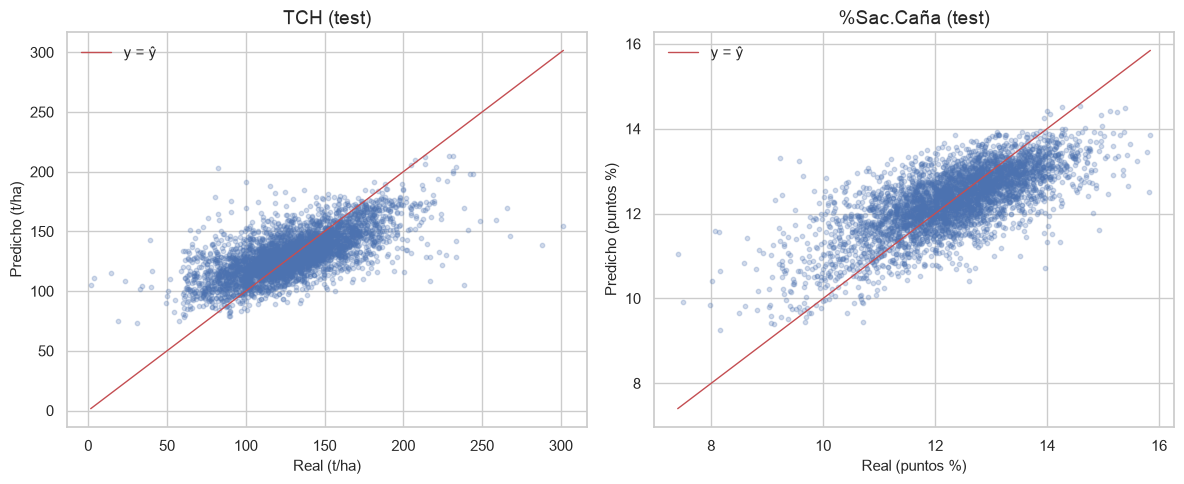

In [15]:
# Mismo gráfico que el OLS del paso 20 (scatter real vs. predicho + línea y = ŷ), ahora con RF en test.
pred_rf_te_tch = rf_tch.predict(X_test)
pred_rf_te_sac = rf_sac.predict(X_test_sac)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y, yhat, titulo, unidad in [
    (axes[0], y_test_tch, pred_rf_te_tch, "TCH (test)", "t/ha"),
    (axes[1], y_test_sac, pred_rf_te_sac, "%Sac.Caña (test)", "puntos %"),
]:
    ax.scatter(y, yhat, s=10, alpha=0.25, color="#4C72B0")
    lo = min(np.min(y), np.min(yhat))
    hi = max(np.max(y), np.max(yhat))
    ax.plot([lo, hi], [lo, hi], color="#C44E52", lw=1, label="y = ŷ")
    ax.set_xlabel(f"Real ({unidad})")
    ax.set_ylabel(f"Predicho ({unidad})")
    ax.set_title(titulo)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**Qué muestra este paso**

Random Forest **sí bajó el error** respecto al OLS del paso 20/21, en las dos respuestas.

- **TCH (test).** OLS: R² = 0.324, RMSE = 26.259 t/ha, MAE = 20.317 t/ha. RF: R² = 0.457, RMSE = 23.524 t/ha, MAE = 17.570 t/ha. El RMSE cae **2.74 t/ha** y el MAE **2.75 t/ha**. En CV del train el salto es del mismo orden (R² 0.301 → 0.437; RMSE 26.074 → 23.403).
- **%Sac.Caña (test).** OLS: R² = 0.350, RMSE = 0.907, MAE = 0.706. RF: R² = 0.505, RMSE = 0.792, MAE = 0.609. El RMSE cae **0.115 puntos porcentuales** de sacarosa y el MAE **0.097**. CV: R² 0.342 → 0.480; RMSE 0.933 → 0.829.
- Ridge y Lasso del paso 21 empataron al OLS (a tres milésimas). El bosque no: recorta el codo de `Cod.Estado #` y la heterocedasticidad que el lineal no puede.

**Importancias vs OLS del paso 18 (variables que el lineal marcó como significativas: `Edad Ult Cos`, `Cod.Estado #`, `Destino 1=Semilla`, `Dosis Madurante`, `Año`, ventanas de lluvia).**

- **Coincide (refuerza el lineal).** En TCH el top del bosque es `Edad Ult Cos` (0.219), `Cod.Estado #` (0.122) y `Año` (0.066). `Dist Km` queda 2.ª (0.132): en el OLS también era significativa (−0.18 t/ha por km). Las ventanas de lluvia entran al top 10 (0–3: 0.032; 9–FC: 0.031). En sacarosa coinciden `Semanas mad.` (0.213), lluvias de 2 meses (0.063), `Cod.Estado #` y cultivo orgánico (0.063).
- **No coincide (no ocultarlo).** `Destino 1=Semilla` **no entra al top 10** de ningún bosque, pese a −21.7 t/ha y p < 0.001 en el OLS. Es un 0/1 raro: el Gini reparte poco entre pocos cortes, y el lineal sí aísla ese salto. En sacarosa el OLS daba el mayor t a `Dosis Madurante` (+0.52 puntos); el RF pone primero `Semanas mad.` y **no mete la dosis en el top 10**. El bloque de maduración ya era colineal (corr dosis–`madurada` ≈ 0.92): el bosque parte por semanas y deja la dosis atrás. `Edad Ult Cos` (0.119) y `Año` (0.062) suben en RF-sacarosa; el OLS ahora sí marca la edad (+0.022, p≈0) y sigue sin marcar el año (p=0.55): ahí el lineal y el no lineal no cuentan la misma historia para `Año`.

**Advertencia metodológica.** `feature_importances_` de `RandomForestRegressor` es importancia Gini / MDI (reducción media de impureza al partir), **no un p-valor** y no se compara 1 a 1 con el OLS. Tiene sesgo conocido a favorecer numéricas continuas (muchos puntos de corte posibles) y a subestimar binarias raras: exactamente el caso de `Destino 1=Semilla`. Lo más riguroso sería contrastar con *permutation importance* (`sklearn.inspection.permutation_importance`) para ver si esas variables realmente pesan menos en el bosque o si es artefacto del MDI. Aquí no se calcula; queda como nota metodológica.

**Ningún identificador de finca o lote es predictor.** `Nombre`, `Hacienda` y `Suerte` se descartaron desde el paso 4 de 01; por eso ninguna categórica del top 10 de importancia (arriba) es un código de finca disfrazado. La pregunta que sí aplica —si el modelo generaliza a un lote que nunca vio— se responde en el paso 20: 89.7 % de las filas de test comparten lote con alguna fila de train, y el error es mayor en el 10.3 % restante (MAE 22.722 vs 20.041 en TCH). Esa es la evidencia de generalización a lote nuevo, no la importancia de una variable categórica.

**Variables climáticas: los tres chequeos, juntos.** Antes de aceptar la correlación lineal baja de las ventanas de lluvia y `Lluvias (2 Meses Ant.)` (paso 10 de 01), se probaron tres chequeos: deciles del target por bin (paso 9 de 01), información mutua (misma celda) y, aquí, la importancia del bosque. Ninguno de los tres las descarta: los deciles muestran diferencias entre grupos, la información mutua no es la más baja del bloque climático, y las cuatro ventanas entran al top 10 de importancia en TCH y `Lluvias (2 Meses Ant.)` al top 5 en sacarosa (arriba). Con al menos dos de tres chequeos a favor —de hecho, los tres—, se mantienen como predictores en vez de descartarlas solo por el correlograma inicial.

**Decisión.** Random Forest gana en RMSE y MAE. El modelo que se interpreta para las decisiones de negocio del Ingenio Providencia **sigue siendo el OLS del paso 18** (signos, magnitudes, p-valores). La desviación de `R²_CV` del bosque (0.014 en TCH, 0.008 en sacarosa) es similar a la del OLS (0.012 y 0.010): el bosque baja el error, no la inestabilidad entre folds. El bosque no los entrega.


In [16]:
# ¿El cultivo orgánico usa menos madurante? (para conectar con el coeficiente de Cultivo en sacarosa)
print(df_tr.groupby("Cultivo").agg(
    pct_madurada=("madurada", lambda s: 100 * s.mean()),
    dosis_media=("Dosis Madurante", "mean"),
    n=("madurada", "size"),
).round(2))


          pct_madurada  dosis_media      n
Cultivo                                   
Normal           55.45         0.55  16213
Organico          0.49         0.01    608


## 23. Conclusiones

Queda un **benchmark lineal interpretable** para `TCH` y `%Sac.Caña`, con hold-out 80/20, supuestos, R² / RMSE / MAE y k-fold en train. La clasificación es `01_eda_ipsa.ipynb` / `02_modelos_clasificacion.ipynb`.

### Qué modelo se queda

**OLS múltiple**, el mismo para leer signos y p-valores. Ridge (α\* = 127.4 en ambos targets) y Lasso empatan el test al segundo decimal: TCH R² = 0.324, RMSE = 26.259 t/ha, MAE = 20.317; sacarosa R² = 0.350, RMSE = 0.907, MAE = 0.706. Con n = 16.538 (TCH) y 16.479 (sacarosa) no hay sobreparametrización que penalizar. Lasso en TCH deja 57/58 coeficientes ≠ 0; en sacarosa, 47/57. Sirven como fila de regularización, no como modelo de negocio.

Random Forest **superó** a OLS/Ridge/Lasso en desempeño puro: RMSE de test 23.524 t/ha vs 26.259 (TCH) y 0.792 vs 0.907 puntos (sacarosa); MAE 17.570 vs 20.317 y 0.609 vs 0.706. No sustituye al OLS para el negocio: el bosque no da signos ni p-valores. Van los dos, con propósitos distintos — **OLS interpreta, RF predice mejor**.

### Validación externa

El TCH medio de este dataset es **129.6 t/ha** (2017–2024, paso 2 de 01). Es coherente con el promedio nacional colombiano de referencia (~120 t/ha) y con la cifra sectorial de 2022 (~127 t/ha), y muy por encima del promedio mundial (~60 t/ha) (Procaña, Asamblea Anual 2024, citada en La República, 7 de junio de 2024). Providencia no está fuera del rango esperado para el sector.

### Desempeño

| Modelo | R² CV train | R² test | RMSE test | MAE test |
|---|---|---|---|---|
| OLS TCH | 0.301 ± 0.012 | **0.324** | **26.259 t/ha** | **20.317 t/ha** |
| OLS %Sac.Caña | 0.342 ± 0.010 | **0.350** | **0.907 puntos** | **0.706 puntos** |
| RF TCH | 0.437 ± 0.014 | **0.457** | **23.524 t/ha** | **17.570 t/ha** |
| RF %Sac.Caña | 0.480 ± 0.008 | **0.505** | **0.792 puntos** | **0.609 puntos** |

Train y test están al mismo nivel (sacarosa incluso un poco mejor en test): no hay sobreajuste. El k-fold confirma el hold-out. Sesgo de test: −1.40 t/ha y −0.008 puntos de sacarosa (casi centrado). MAE/TCH ≈ 20.3 sobre una media de ~131 t/ha: el lineal acierta el orden de magnitud, no el lote. RMSE > MAE encaja con la heterocedasticidad del paso 19.

En los extremos de sacarosa el lineal **no alerta bien**: MAE 1.339 (decil bajo) y 1.302 (decil alto) frente a 0.706 global. Pierde precisión justo en los lotes de desempeño más bajo y más alto.

### Qué variables mandan (OLS)

**TCH (productividad)** — n = **20.672** lotes (sin `excluir_tch`).

- `Edad Ult Cos`: **+4.59 t/ha por mes** de ciclo. Es el predictor numérico más claro.
- `Destino 1=Semilla`: **−21.7 t/ha**. Semillero, no molino.
- `Cod.Estado #`: **−0.63 t/ha por corte**. La soca pierde desde la plantilla (paso 11); el lineal pone una recta sobre un codo. — agronómicamente, cada corte adicional sobre la misma cepa (soca) reduce el vigor de rebrote: menos raíces nuevas y más competencia por nutrientes del suelo que en la plantilla; es un patrón conocido en caña de azúcar, no un artefacto del dato.
- `Año` (desde 2017): **−3.29 t/ha/año**. Tendencia a la baja en el histórico. Coherente, al menos en parte, con lo reportado por el sector (Procaña, 2024): el TCH nacional cayó de ~127 a ~102 t/ha entre 2022 y 2024, atribuido al exceso de lluvia de La Niña (1.288 → 1.600 mm/año) y a cosechas forzadas más jóvenes (>50 % de lotes con menos de 12 meses). El evento reportado cubre sobre todo 2021 en adelante; el coeficiente de este modelo mide una tendencia lineal desde 2017, así que es una explicación parcial y externa, no confirmada dentro de este dataset. — el notebook no aísla una causa única: candidatas razonables son desgaste del suelo en plantaciones más viejas, cambio de variedades dominantes en el histórico, o presión de mercado sobre el manejo; ninguna se confirma aquí, y no debe leerse como una causa establecida.
- Distancia al ingenio negativa y pequeña; `M3 Riego` positivo; **`Num.Riegos` no significativo**. — el signo es coherente con más tiempo de acarreo, pero el punto de referencia de `Dist Km` no se confirmó con certeza (paso 9); la magnitud (−0.18 t/ha por km) es chica y la lectura causal es tentativa. Antes de aceptar esa correlación lineal baja como definitiva, `Dist Km` y `Num.Riegos` se investigaron con bins por decil, información mutua y (en el caso de las ventanas de lluvia) importancia del bosque, además de verificar que su rango observado no fuera artificialmente restringido (paso 10 de 01): `Dist Km` mostró la información mutua más alta de ese bloque (0.0817) y un rango amplio (1.1 a 155 km), así que se mantiene como predictor pese a Pearson bajo; `Num.Riegos` sí quedó consistentemente poco informativo en los tres chequeos y su falta de significancia en el OLS es coherente con eso, no un descarte apresurado.
- Ventanas de lluvia (reemplazan a `Lluvias Ciclo`): 0–3 y 3–6 **negativas**; 6–9 y 9–cosecha **positivas**. `lluvia_sin_dato`: **−7.09 t/ha**.
- Zona IP02/IP03/IP05 por encima de la referencia; CC05-430 sube TCH; CC85-92 y CC93-4418 lo bajan. — las zonas no son solo geografía: `Suelo` y `Zona` están asociadas (Cramér's V ≈ 0.23, paso 14), así que parte de la diferencia entre zonas puede venir de sus suelos dominantes, no solo de la ubicación en sí.

**`%Sac.Caña` (calidad)**

- `Dosis Madurante`: **+0.52 puntos** por unidad. Palanca de maduración sobre la calidad. — el madurante (trinexapac-etil, familia Bonus/Optimus/Tronnuspac ya identificada en el paso 9) inhibe la síntesis de giberelina, lo que frena el crecimiento vegetativo del tallo y redirige el metabolismo hacia la acumulación de sacarosa: el signo positivo es el efecto esperado del producto, no una coincidencia estadística.
- Lluvias de **2 meses antes** y de **9–cosecha**: signo **negativo** (dilución en maduración).
- Cultivo **orgánico: −1.08 puntos**. El manejo orgánico aplica madurante con mucha menor frecuencia (0.49 % vs 55.45 %, dosis media 0.01 vs 0.55): la menor sacarosa no es un efecto directo de ser orgánico, es consecuencia de prescindir del químico que más la sube (`Dosis Madurante`, arriba).
- Edad de *este* ciclo **sí mueve** la sacarosa (+0.022, p≈0); el número de corte, apenas. Destino semilla no es significativo en calidad.
- CC93-4418 a favor de azúcar y en contra de TCH: no hay una variedad que gane los dos objetivos.

### Supuestos

Linealidad aproximada, rota en la soca. Homocedasticidad no: abanico con el TCH predicho (lotes chicos). Residuos casi simétricos; Q-Q se sale en colas. Filas no independientes (la misma suerte en varios periodos): p-valores del paso 18 **optimistas**. El lineal es interpretable, no el proceso generador. La mayor distancia de Cook (**93.61**) no es la fila de 78.19 meses: es un semillero de 8.25 meses (TCH 65.04).

### Limitaciones

1. **Sin fertilización** (80–100% nulos). El factor agronómico existe; el histórico no lo mide. Próxima iteración: gestionar con el Ingenio el registro sistemático de fertilización por lote.
2. **`lluvia_sin_dato`** marca ceros de lluvia como faltante; las ventanas del ciclo sí entran al lineal, con signos opuestos según la fase. El efecto no es un solo total anual. Próxima iteración: confirmar con el Ingenio si esos ceros son sequía real o vacío de captura, lote por lote.
3. **R² ≈ 0.31–0.35** en OLS: queda ~69% del TCH sin explicar. Un árbol baja el RMSE; no se interpreta igual. El chequeo de 01 (lluvia 0–3 × variedad, n ≥ 500) muestra interacción: Pearson de −0.262 (`CC05-430`) a +0.033 (`RB73-2223`) frente a −0.144 global; 2 de 4 términos `Lluvias_0_3 × C(Variedad)` son significativos (`CC05-430` y `RB73-2223`, p = 0.0000). Próxima iteración: probar ese término en el lineal, o un GAM que capture no linealidad sin perder interpretabilidad.
4. Extremos de TCH en 0.1–2 ha: error de denominador, no productividad. No se borraron; MAE es la métrica de trabajo. Los extremos de sacarosa concentran el error (paso 20). Próxima iteración: modelar el error por segmento (deciles) directamente, no solo el promedio global.
5. `Período` partido en Año + Mes; `Tipo Quema = SEMILLA` era destino (colinealidad exacta).
6. **Alcance del dataset.** `HISTORICO_SUERTES` cubre una población amplia de lotes (maduradas y no maduradas, cosecha mecánica y manual, 58 variedades), no un subconjunto preseleccionado. Las conclusiones de estos modelos aplican a esa población general del Ingenio Providencia, no a un recorte específico de manejo. Próxima iteración: contrastar explícitamente con el alcance del dataset de clasificación (`BD_IPSA_1940`) al comparar hallazgos entre ambos modelos.
7. **Vacíos temporales en variables climáticas.** La estación meteorológica no tiene datos entre 2017 y comienzos de 2022 (primer período con dato: febrero de 2022, paso 9 de 01); después tampoco es total (56–66 % de cobertura por año). Por eso queda fuera del lineal. Se evaluaron tres alternativas y se descartaron a favor de excluirla del todo (razonamiento completo en el paso 9 de 01). Próxima iteración: usar esa fuente solo desde 2022 como modelo complementario, o buscar una reconstrucción histórica externa (IDEAM, Cenicaña) para el tramo 2017–2021.
8. **Variables sin significado confirmado con certeza.** `Dist Km` (Razonable–alta la unidad, pero el punto de referencia —¿el ingenio?— no se confirmó, paso 9); `Tenencia` (códigos 11/28/31/51/81/82/91 sin traducción en el diccionario ni en fuentes externas, Ambigua residual; el paso 16 agrupa en `OTRAS` los códigos con menos de 200 filas en train —82 y 91—, sin que eso resuelva su significado); `D.S.` (inferido como distanciamiento de siembra en metros con confianza razonable, pero las filas marcadas `DS` siguen sin explicación). Ninguna de las tres cambia el modelo actual (`Dist Km` sí entra a X con esa salvedad; `Tenencia_agrup` entra dummy, paso 16, sin traducción de códigos; `D.S.` no es predictor). Próxima iteración: confirmar directamente con el Ingenio el punto de referencia de `Dist Km` y el significado de los códigos de `Tenencia`.
9. **Una fila con apalancamiento extremo.** `T.Corte_agrup = OTRAS` (el `SEMILLA` recodificado del paso 16) tiene una sola fila en train; esa fila queda con leverage = 1.0 y distancia de Cook = 93.61 (paso 19), porque el lineal la interpola exactamente. Es un semillero de ciclo corto (`Edad Ult Cos` 8.25, TCH 65.04), no un error de datos. Agrupar categorías con muy pocas filas en `OTRAS` (como se hizo con `Tenencia`, ítem 8) reduce coeficientes inestables, pero puede concentrar apalancamiento cuando el grupo `OTRAS` mismo queda con una sola fila. Próxima iteración: fusionar `T.Corte = SEMILLA` con `NO DEF.` en vez de con `OTRAS` (ambos son "no clasificado" en el sentido productivo), para que ninguna dummy quede en una sola fila.

### Qué hacer con esto en Providencia

- Esto significa que el Ingenio podría adelantar la renovación de socas con muchos cortes (`Cod.Estado #`: **−0.63 t/ha por corte**, paso 18/23) y cuidar que el ciclo llegue a una edad suficiente (`Edad Ult Cos`: **+4.59 t/ha por mes**) para recuperar vigor de rebrote y toneladas por hectárea, en lugar de dejar que la cepa envejezca corte tras corte.
- Esto significa que el Ingenio podría reportar y comparar los semilleros aparte de los lotes de molino (`Destino 1=Semilla`: **−21.7 t/ha**, paso 18) para no tratar un TCH bajo esperado como un fallo de manejo y no mezclar esas filas en el indicador de productividad comercial.
- Esto significa que el Ingenio podría esperar menos sacarosa en lotes orgánicos (madurante en **0.49 %** de esas filas frente a **55.45 %** en `Normal`) y, donde el manejo lo permite, usar `Dosis Madurante` (**+0.52 puntos**, paso 18) como palanca de calidad: el trinexapac-etil frena el crecimiento vegetativo y empuja la acumulación de azúcar.
- Esto significa que el Ingenio podría seguir la lluvia por fase del ciclo, no solo el total anual (paso 18: 0–3 y 3–6 **negativas** en TCH; 6–9 y 9–cosecha **positivas**; 2 meses antes y 9–cosecha **negativas** en sacarosa) para anticipar si el agua de ese tramo empuja toneladas o diluye calidad.
- Esto significa que el Ingenio podría no fiarse de la predicción puntual de sacarosa para decidir si un lote es crítico (paso 20: MAE **1.339** / **1.302** en los deciles extremos frente a **0.706** global) y usarla solo como primera alerta que se verifica en campo antes de intervenir, porque el error es mayor justo en los lotes de peor y mejor desempeño.
- Esto significa que el Ingenio podría tratar con más cautela la predicción en una finca o lote que nunca ha reportado datos (paso 20: **89.7 %** de las filas de test ya tenían el lote en train; MAE **22.722** vs **20.041** en TCH y **0.825** vs **0.693** en sacarosa para lote nuevo vs visto) porque el error esperado ahí es mayor que el de las métricas generales de test.
- Esto significa que el Ingenio podría usar el OLS para priorizar qué palancas de manejo mover primero en la próxima campaña (edad, destino, dosis, fase de la lluvia), no para fijar una meta de TCH exacta por lote: el lineal ordena magnitudes, no pronostica al decimal.
